# Ciblage des aides publiques à partir du recensement américain (dataset *Adult*)

**Projet de Data Mining – Politique sociale / ciblage des aides publiques**

Ce notebook suit la démarche CRISP-DM :

1. Business Understanding
2. Data Understanding
3. Data Exploration
4. Data Preparation
5. Segmentation
6. Classification
7. Évaluation et interprétation des résultats

> **Le notebook part uniquement des fichiers bruts** `adult.data` et `adult.test`, tels que fournis par l'UCI. Ils doivent se trouver dans le dossier indiqué par `DATA_DIR`. Tout le nettoyage, les transformations et la modélisation sont faits ici.

In [58]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, cross_validate
from sklearn.inspection import permutation_importance
from sklearn.metrics import (silhouette_score, accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                             precision_recall_curve, average_precision_score, log_loss,
                             brier_score_loss, matthews_corrcoef, cohen_kappa_score,
                             classification_report)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
# Détection automatique de l'environnement : Google Colab ou Jupyter en local
try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

# Sur Colab, les fichiers sont envoyés dans /content (cellule suivante).
# En local, mettez adult.data et adult.test dans le même dossier que ce notebook
# (ou indiquez le chemin, ex. r"C:\Users\nom\Downloads\adult").
DATA_DIR = "/content" if EN_COLAB else "."
print("Environnement :", "Google Colab" if EN_COLAB else "local", "| DATA_DIR =", DATA_DIR)

Environnement : Google Colab | DATA_DIR = /content


In [59]:
# Chargement des fichiers bruts (sur Colab : fenêtre d'envoi si les fichiers sont absents)
import os
if EN_COLAB:
    for f in os.listdir(DATA_DIR):                      # supprime les doublons "adult (1).data"…
        if f.startswith("adult ("):
            os.remove(os.path.join(DATA_DIR, f))
    if not all(os.path.exists(f"{DATA_DIR}/{f}") for f in ["adult.data", "adult.test"]):
        from google.colab import files
        print("Sélectionnez adult.data ET adult.test (Ctrl + clic pour choisir les deux)")
        files.upload()

for f in ["adult.data", "adult.test"]:
    assert os.path.exists(f"{DATA_DIR}/{f}"), f"Fichier introuvable : {DATA_DIR}/{f}"
print("Fichiers bruts trouvés :", [f for f in ["adult.data", "adult.test"]])

Fichiers bruts trouvés : ['adult.data', 'adult.test']


---
# 1. Business Understanding

## 1.1 Contexte
Les politiques sociales (aides au logement, allocations, formation, accompagnement vers l'emploi…) disposent de budgets limités. Une administration doit donc **cibler** les personnes qui en ont le plus besoin. Elle ne connaît pas toujours le revenu exact des individus, mais dispose souvent d'informations socio-démographiques : âge, diplôme, emploi, situation familiale, temps de travail.

Le dataset *Adult* a été extrait du recensement américain de 1994. Il décrit environ 48 000 adultes et indique si leur revenu annuel dépasse 50 000 $.

## 1.2 Problématique
> **Peut-on identifier et caractériser les personnes à revenus modestes à partir de leurs caractéristiques socio-démographiques, afin de mieux cibler les aides publiques ?**

## 1.3 Objectifs
| Objectif métier | Objectif Data Mining |
|---|---|
| Comprendre **qui** sont les personnes à revenus modestes | **Exploration** des facteurs liés au revenu |
| Concevoir des politiques **adaptées à chaque profil** | **Segmentation** (clustering) de la population |
| **Repérer automatiquement** les bénéficiaires potentiels | **Classification** binaire : revenu ≤ 50K (cible de l'aide) vs > 50K |
| Garantir une attribution **juste et explicable** | **Interprétation** des modèles et **analyse d'équité** |

## 1.4 Définition de la cible
Nous créons la variable `cible_aide` :
- `cible_aide = 1` : revenu **≤ 50K** → bénéficiaire potentiel de l'aide (classe d'intérêt) ;
- `cible_aide = 0` : revenu **> 50K** → non prioritaire.

## 1.5 Le coût des erreurs
| Erreur | Signification | Conséquence |
|---|---|---|
| **Faux négatif** (erreur d'exclusion) | Une personne modeste est classée « aisée » | Elle **ne reçoit pas l'aide** : coût social, injustice |
| **Faux positif** (erreur d'inclusion) | Une personne aisée est classée « modeste » | **Fuite budgétaire** : argent public mal dirigé |

Les deux erreurs comptent, mais l'exclusion est jugée **plus grave** dans une politique sociale. Nous suivrons donc explicitement le **taux d'exclusion** et le **taux d'inclusion**, en plus des métriques classiques.

## 1.6 Critères de succès
- Faire nettement mieux que le modèle naïf (« tout le monde est modeste » donne déjà ≈ 76 % d'accuracy) ;
- ROC-AUC supérieure à 0,85 ;
- Un modèle **explicable** à un citoyen ou à un agent administratif ;
- Des écarts d'erreur limités entre groupes (sexe, origine).

## 1.7 Limites à garder en tête
- Les données datent de **1994** et concernent les **États-Unis**.
- 50 000 $ n'est **pas le seuil de pauvreté** (≈ 15 000 $ pour une famille de 4 en 1994). Le seuil sépare plutôt les revenus modestes et moyens des revenus aisés.
- Le revenu est **individuel**, alors que beaucoup d'aides sont calculées au niveau du **foyer**.

---
# 2. Data Understanding

## 2.1 Les fichiers fournis
| Fichier | Contenu |
|---|---|
| `adult.data` | Jeu d'entraînement (32 561 lignes) |
| `adult.test` | Jeu de test (16 281 lignes) |
| `adult.names` | Documentation : variables, méthode d'extraction, scores de référence |
| `old_adult.names`, `Index` | Ancienne documentation et index (inutiles pour l'analyse) |

Les fichiers **n'ont pas d'en-tête** : il faut nommer les colonnes au chargement.

In [60]:
# Aperçu brut des premières lignes : on repère d'éventuelles anomalies de format
for f in ["adult.data", "adult.test"]:
    print(f"--- {f} ---")
    with open(f"{DATA_DIR}/{f}") as fh:
        for _ in range(3):
            print(repr(fh.readline()))

--- adult.data ---
'39, State-gov, 77516, Bachelors, 13, Never-married, Adm-clerical, Not-in-family, White, Male, 2174, 0, 40, United-States, <=50K\n'
'50, Self-emp-not-inc, 83311, Bachelors, 13, Married-civ-spouse, Exec-managerial, Husband, White, Male, 0, 0, 13, United-States, <=50K\n'
'38, Private, 215646, HS-grad, 9, Divorced, Handlers-cleaners, Not-in-family, White, Male, 0, 0, 40, United-States, <=50K\n'
--- adult.test ---
'|1x3 Cross validator\n'
'25, Private, 226802, 11th, 7, Never-married, Machine-op-inspct, Own-child, Black, Male, 0, 0, 40, United-States, <=50K.\n'
'38, Private, 89814, HS-grad, 9, Married-civ-spouse, Farming-fishing, Husband, White, Male, 0, 0, 50, United-States, <=50K.\n'


**Anomalies de format repérées :**
- un **espace** suit chaque virgule (`', State-gov'`) ;
- la **première ligne de `adult.test`** est parasite (`|1x3 Cross validator`) ;
- dans `adult.test`, les labels se terminent par un **point** (`<=50K.`).

In [61]:
COLS = ["age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
        "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
        "hours_per_week", "native_country", "income"]

# skipinitialspace supprime l'espace après chaque virgule ; skiprows=1 ignore la ligne parasite du test
train_raw = pd.read_csv(f"{DATA_DIR}/adult.data", header=None, names=COLS, skipinitialspace=True)
test_raw  = pd.read_csv(f"{DATA_DIR}/adult.test", header=None, names=COLS, skipinitialspace=True, skiprows=1)

print("Train :", train_raw.shape, "| Test :", test_raw.shape)
train_raw.head()

Train : (32561, 15) | Test : (16281, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2.2 Dictionnaire des variables
| Variable | Type | Description |
|---|---|---|
| `age` | numérique | Âge de la personne |
| `workclass` | catégorielle | Type d'employeur (privé, public, indépendant…) |
| `fnlwgt` | numérique | *Final weight* : poids d'échantillonnage du recensement (nombre de personnes que la ligne représente) |
| `education` | catégorielle | Diplôme le plus élevé (16 niveaux) |
| `education_num` | numérique | Le même diplôme codé de 1 (Preschool) à 16 (Doctorate) |
| `marital_status` | catégorielle | Situation matrimoniale |
| `occupation` | catégorielle | Métier |
| `relationship` | catégorielle | Rôle dans le foyer (Husband, Wife, Own-child…) |
| `race` | catégorielle | Origine ethnique (**variable sensible**) |
| `sex` | catégorielle | Sexe (**variable sensible**) |
| `capital_gain` / `capital_loss` | numériques | Plus-values / moins-values en capital |
| `hours_per_week` | numérique | Heures travaillées par semaine |
| `native_country` | catégorielle | Pays d'origine |
| `income` | **cible** | ≤50K ou >50K |

In [62]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [63]:
# Modalités de la variable cible : le test contient des labels avec un point final
print("Train :", train_raw["income"].unique())
print("Test  :", test_raw["income"].unique())

Train : ['<=50K' '>50K']
Test  : ['<=50K.' '>50K.']


In [64]:
# Les valeurs manquantes sont codées "?" (et non vides) : isna() ne les détecte pas !
manq = pd.DataFrame({
    "isna() train": train_raw.isna().sum(),
    "'?' train": (train_raw == "?").sum(),
    "'?' test": (test_raw == "?").sum(),
})
manq["% '?' train"] = 100 * manq["'?' train"] / len(train_raw)
manq[manq["'?' train"] > 0]

,isna() train,'?' train,'?' test,% '?' train
workclass,0,1836,963,5.639
occupation,0,1843,966,5.660
native_country,0,583,274,1.790


In [65]:
print("Doublons exacts – train :", train_raw.duplicated().sum(), "| test :", test_raw.duplicated().sum())
print("\nNombre de modalités par variable catégorielle :")
train_raw.select_dtypes("object").nunique().sort_values(ascending=False)

Doublons exacts – train : 24 | test : 5

Nombre de modalités par variable catégorielle :


,0
native_country,42
education,16
occupation,15
workclass,9
marital_status,7
relationship,6
race,5
sex,2
income,2


In [66]:
train_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
age,"32,561.000",38.582,13.640,17.000,28.000,37.000,48.000,90.000
fnlwgt,"32,561.000","189,778.367","105,549.978","12,285.000","117,827.000","178,356.000","237,051.000","1,484,705.000"
education_num,"32,561.000",10.081,2.573,1.000,9.000,10.000,12.000,16.000
capital_gain,"32,561.000","1,077.649","7,385.292",0.000,0.000,0.000,0.000,"99,999.000"
capital_loss,"32,561.000",87.304,402.960,0.000,0.000,0.000,0.000,"4,356.000"
hours_per_week,"32,561.000",40.437,12.347,1.000,40.000,40.000,45.000,99.000


## 2.3 Synthèse de la qualité des données
| # | Problème | Variables concernées |
|---|---|---|
| 1 | Valeurs manquantes codées `"?"` | `workclass`, `occupation`, `native_country` |
| 2 | Format : espaces, ligne parasite, labels du test avec un point | fichiers bruts, `income` |
| 3 | Doublons exacts | quelques dizaines de lignes |
| 4 | Variables redondantes | `education` ↔ `education_num` |
| 5 | Distributions très asymétriques, valeur plafond 99 999 | `capital_gain`, `capital_loss` |
| 6 | Catégories rares ou très dominantes | `native_country`, `workclass`, `occupation`, `race` |
| 7 | Variable technique sans sens individuel | `fnlwgt` |
| 8 | Classes déséquilibrées (≈ 76 / 24) | `income` |

Nous vérifions et quantifions ces points dans l'exploration, puis nous les traitons dans la préparation.

---
# 3. Data Exploration

On réunit train et test et on harmonise uniquement les labels et les `"?"`. Le reste du nettoyage se fait en partie 4.

In [67]:
eda = pd.concat([train_raw, test_raw], ignore_index=True).replace("?", np.nan)
eda["income"] = eda["income"].str.rstrip(".")
eda["cible_aide"] = (eda["income"] == "<=50K").astype(int)
print(eda.shape)

(48842, 16)


## 3.1 Variable cible

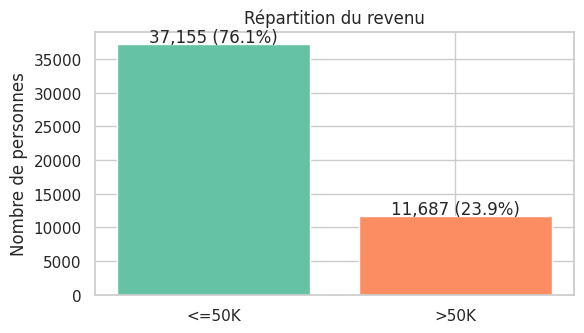

In [68]:
fig, ax = plt.subplots(figsize=(6, 3.5))
counts = eda["income"].value_counts()
ax.bar(counts.index, counts.values, color=["#66c2a5", "#fc8d62"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 300, f"{v:,} ({v/len(eda):.1%})", ha="center")
ax.set_title("Répartition du revenu"); ax.set_ylabel("Nombre de personnes")
plt.tight_layout(); plt.show()

Les classes sont **déséquilibrées** : environ 76 % des personnes ont un revenu modeste. Un modèle qui répondrait toujours « ≤50K » aurait déjà 76 % d'accuracy. L'accuracy seule ne suffit donc pas pour évaluer nos modèles.

## 3.2 Variables numériques

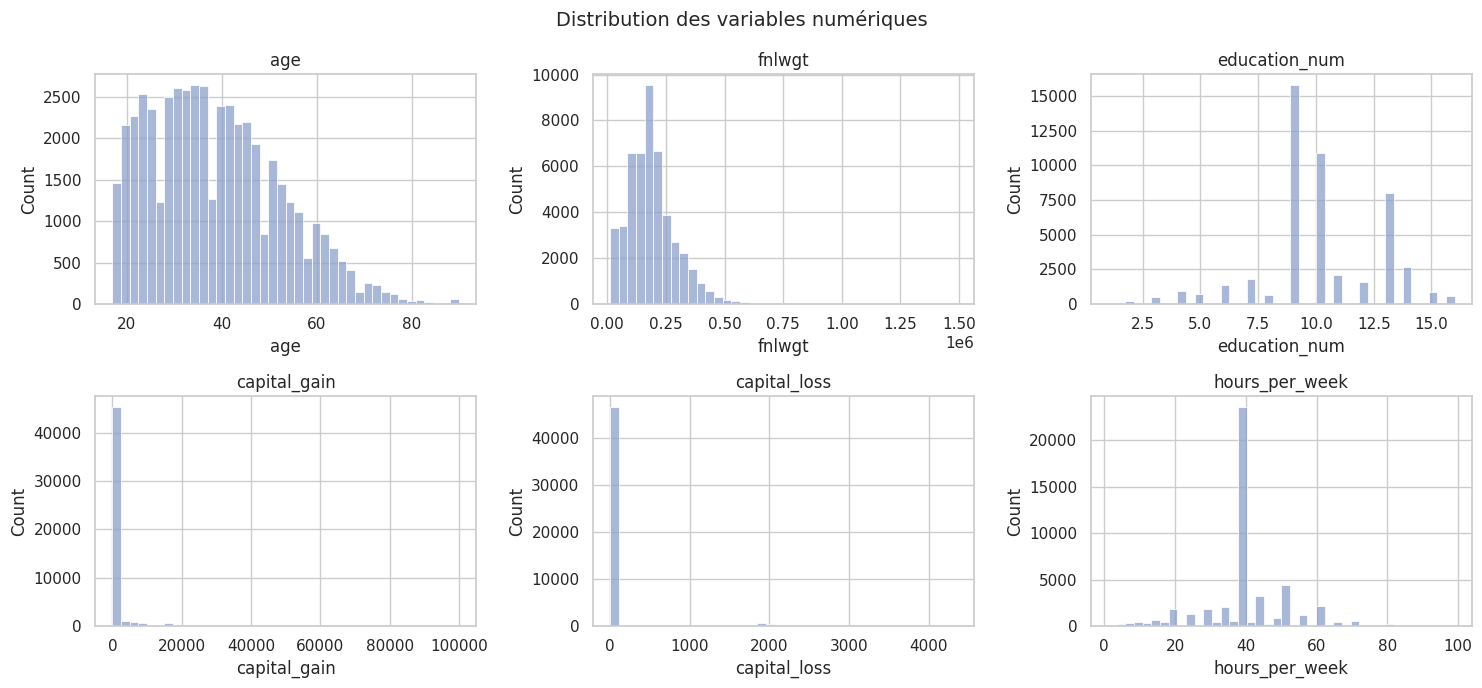

In [69]:
num_cols = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(eda[c], bins=40, ax=ax, color="#8da0cb")
    ax.set_title(c)
plt.suptitle("Distribution des variables numériques", fontsize=14)
plt.tight_layout(); plt.show()

In [70]:
print(f"capital_gain = 0      : {(eda.capital_gain == 0).mean():.1%}")
print(f"capital_loss = 0      : {(eda.capital_loss == 0).mean():.1%}")
print(f"capital_gain = 99 999 : {(eda.capital_gain == 99999).sum()} lignes (valeur plafond)")
print(f"hours_per_week = 99   : {(eda.hours_per_week == 99).sum()} lignes")
print(f"hours_per_week = 40   : {(eda.hours_per_week == 40).mean():.1%}")
print(f"âge min / max         : {eda.age.min()} / {eda.age.max()}")

capital_gain = 0      : 91.7%
capital_loss = 0      : 95.3%
capital_gain = 99 999 : 244 lignes (valeur plafond)
hours_per_week = 99   : 137 lignes
hours_per_week = 40   : 46.7%
âge min / max         : 17 / 90


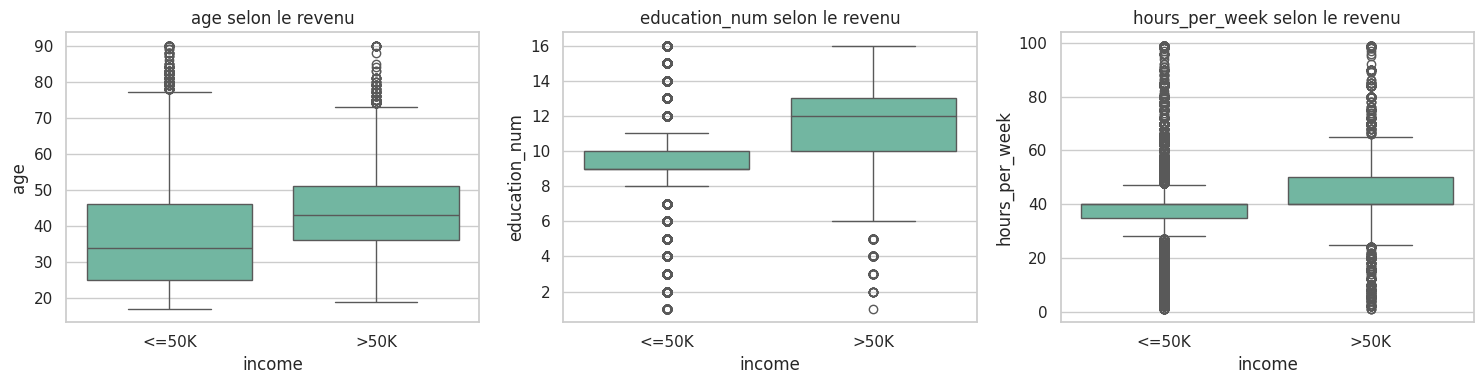

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, ["age", "education_num", "hours_per_week"]):
    sns.boxplot(data=eda, x="income", y=c, ax=ax, order=["<=50K", ">50K"])
    ax.set_title(f"{c} selon le revenu")
plt.tight_layout(); plt.show()

## 3.3 Facteurs associés au revenu modeste

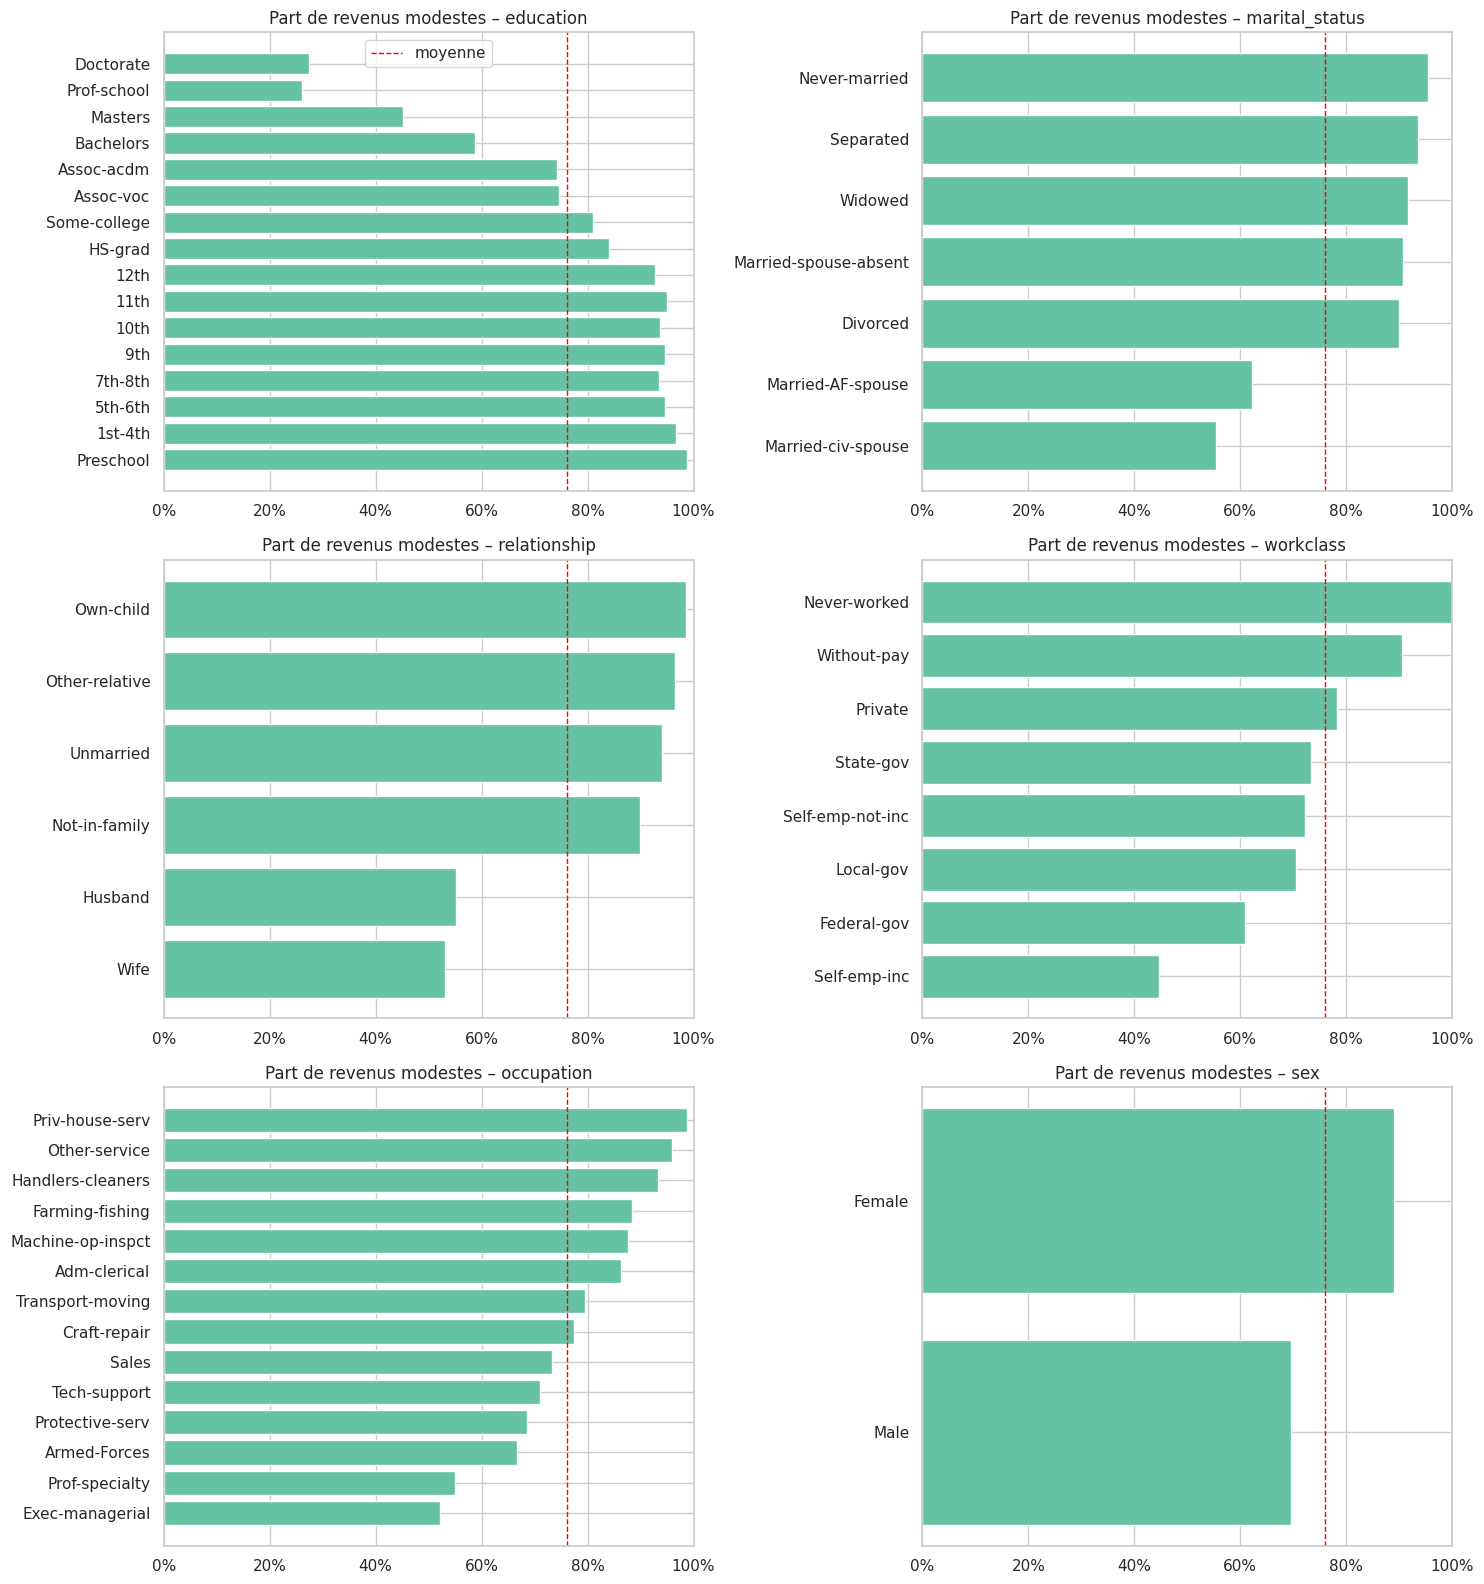

In [72]:
def barres_taux(col, ax, order=None, top=None):
    # Part de personnes à revenu modeste (cible_aide = 1) par modalité
    t = eda.groupby(col)["cible_aide"].agg(["mean", "size"])
    t = t.loc[order] if order is not None else t.sort_values("mean")
    if top: t = t.tail(top)
    ax.barh(t.index.astype(str), t["mean"], color="#66c2a5")
    ax.axvline(eda["cible_aide"].mean(), color="red", ls="--", lw=1, label="moyenne")
    ax.set_xlim(0, 1); ax.set_title(f"Part de revenus modestes – {col}")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

edu_order = eda.groupby("education")["education_num"].first().sort_values().index
fig, axes = plt.subplots(3, 2, figsize=(15, 16))
barres_taux("education", axes[0, 0], order=edu_order)
barres_taux("marital_status", axes[0, 1])
barres_taux("relationship", axes[1, 0])
barres_taux("workclass", axes[1, 1])
barres_taux("occupation", axes[2, 0])
barres_taux("sex", axes[2, 1])
axes[0, 0].legend()
plt.tight_layout(); plt.show()

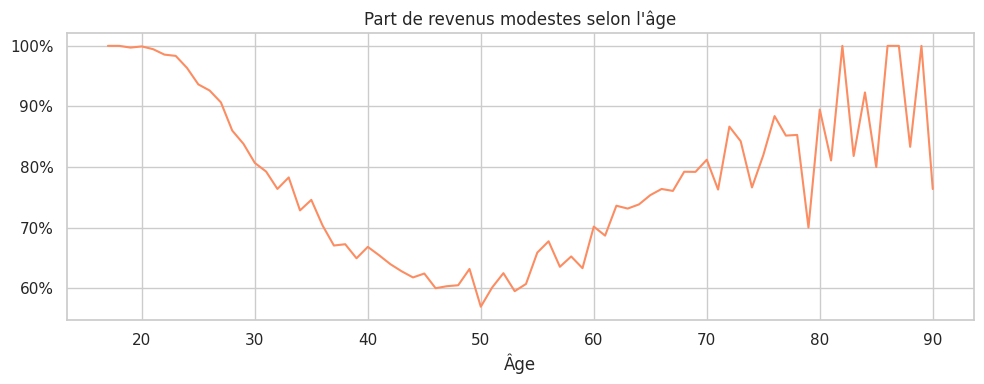

In [73]:
age_rate = eda.groupby("age")["cible_aide"].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(age_rate.index, age_rate.values, color="#fc8d62")
ax.set_title("Part de revenus modestes selon l'âge"); ax.set_xlabel("Âge")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout(); plt.show()

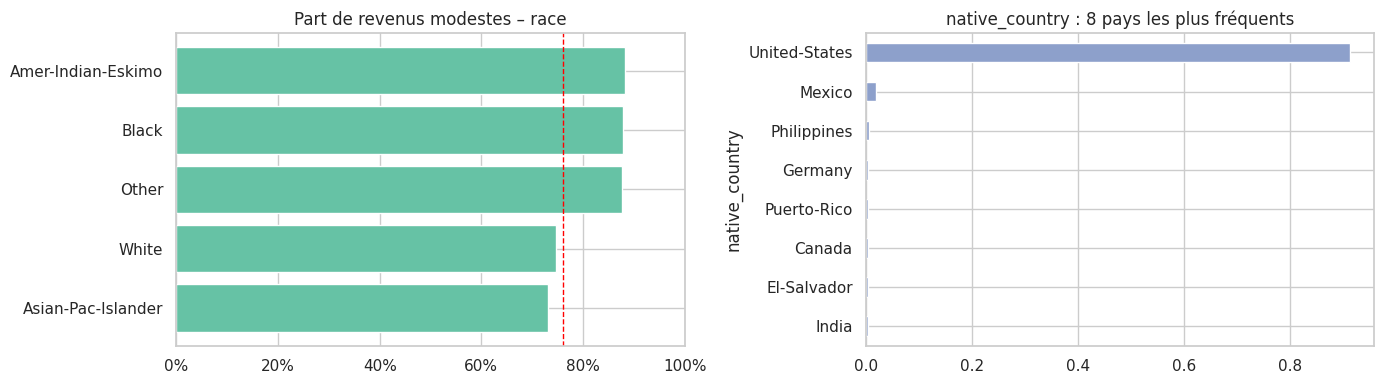

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
barres_taux("race", axes[0])
eda["native_country"].value_counts(normalize=True).head(8).plot.barh(ax=axes[1], color="#8da0cb")
axes[1].set_title("native_country : 8 pays les plus fréquents"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 3.4 Corrélations et redondances

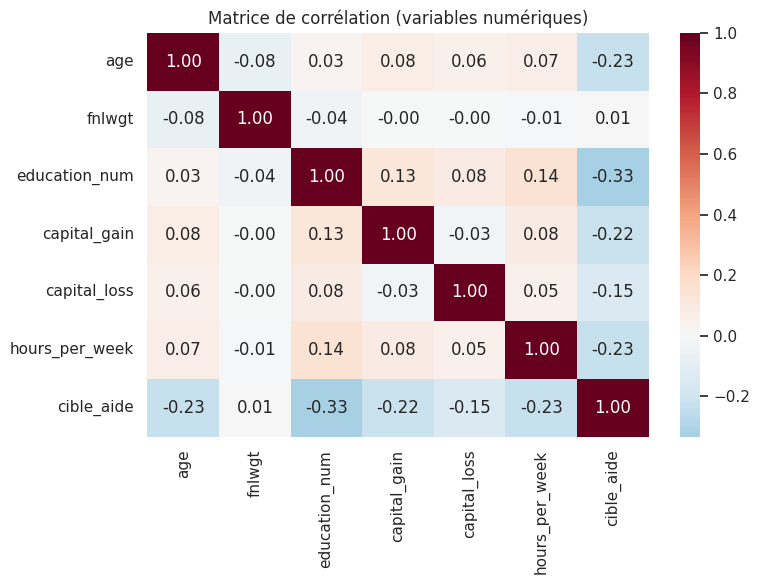

In [75]:
corr = eda[num_cols + ["cible_aide"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Matrice de corrélation (variables numériques)")
plt.tight_layout(); plt.show()

In [76]:
# education et education_num : chaque diplôme correspond à exactement un code
mapping = eda.groupby("education")["education_num"].nunique()
print("Nombre de codes education_num par diplôme :", mapping.unique())
eda.groupby("education")["education_num"].first().sort_values()

Nombre de codes education_num par diplôme : [1]


,education_num
education,
Preschool,1
1st-4th,2
5th-6th,3
7th-8th,4
9th,5
10th,6
11th,7
12th,8
HS-grad,9


In [77]:
# relationship et marital_status se recoupent : Husband/Wife => marié
pd.crosstab(eda["relationship"], eda["marital_status"])

marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
relationship,,,,,,,
Husband,0,12,19704,0,0,0,0
Not-in-family,3628,0,23,330,7114,637,851
Other-relative,181,1,201,54,920,79,70
Own-child,455,1,143,61,6750,146,25
Unmarried,2369,0,0,183,1333,668,572
Wife,0,23,2308,0,0,0,0


## 3.5 Nature des valeurs manquantes

In [78]:
print(pd.crosstab(eda["workclass"].isna(), eda["occupation"].isna(),
                  rownames=["workclass manquant"], colnames=["occupation manquant"]))
print("\nPersonnes 'Never-worked' : occupation =", eda.loc[eda.workclass == "Never-worked", "occupation"].unique())

taux_manq = eda["cible_aide"].groupby(eda["workclass"].isna()).mean()
print(f"\nPart de revenus modestes – workclass manquant : {taux_manq[True]:.1%} vs renseigné : {taux_manq[False]:.1%}")
print("Âge moyen – workclass manquant :", round(eda.loc[eda.workclass.isna(), "age"].mean(), 1),
      "vs renseigné :", round(eda.loc[eda.workclass.notna(), "age"].mean(), 1))

occupation manquant  False  True 
workclass manquant               
False                46033     10
True                     0   2799

Personnes 'Never-worked' : occupation = [nan]

Part de revenus modestes – workclass manquant : 90.5% vs renseigné : 75.2%
Âge moyen – workclass manquant : 40.1 vs renseigné : 38.6


## 3.6 Principales observations
- **Déséquilibre** : environ 76 % de revenus modestes et 24 % de revenus aisés.
- **Éducation** : c'est le facteur le plus discriminant. Sans le bac, plus de 90 % des personnes ont un revenu modeste. Ce taux tombe à environ 25 % avec un doctorat.
- **Âge** : relation **non linéaire**, en forme de U. Les jeunes (< 25 ans) sont presque tous modestes. Le taux est au plus bas vers 45–55 ans, puis remonte après 60 ans.
- **Situation familiale** : environ 95 % des célibataires ont un revenu modeste, contre environ 55 % des personnes mariées. `relationship` et `marital_status` portent une information proche.
- **Sexe** : environ 89 % des femmes ont un revenu modeste, contre environ 69 % des hommes.
- **Emploi** : les métiers de service, d'entretien ou de manutention et le travail à temps partiel sont associés aux revenus modestes.
- **Capital** : plus de 90 % de zéros. Le simple fait d'avoir des plus-values signale souvent un revenu élevé.
- **Valeurs manquantes non aléatoires** : `workclass` et `occupation` manquent **ensemble**. Ces personnes sont plus souvent modestes (≈ 90 % contre 75 %). On y trouve beaucoup de très jeunes et de seniors, probablement des étudiants et des retraités. L'absence d'information est donc **elle-même informative**.

---
# 4. Data Preparation

Chaque transformation est justifiée. Les problèmes de la section 2.3 sont traités dans l'ordre.

## 4.1 Fusion, format et harmonisation de la cible

In [79]:
df = pd.concat([train_raw.assign(split="train"), test_raw.assign(split="test")], ignore_index=True)
n_initial = len(df)
df = df.replace("?", np.nan)                    # "?" -> vraie valeur manquante
df["income"] = df["income"].str.rstrip(".")      # "<=50K." -> "<=50K"
for c in df.select_dtypes("object"):
    df[c] = df[c].str.strip()                    # sécurité : espaces résiduels
print(df["income"].value_counts())

income
<=50K    37155
>50K     11687
Name: count, dtype: int64


On garde une colonne `split` pour **conserver le découpage train/test d'origine**. Cela évite toute fuite d'information : les paramètres de normalisation, d'imputation et des modèles sont calculés sur le train uniquement.

## 4.2 Doublons

In [80]:
cols_sans_split = [c for c in df.columns if c != "split"]
n_dup = df.duplicated(subset=cols_sans_split).sum()
df = df.drop_duplicates(subset=cols_sans_split).reset_index(drop=True)
print(f"{n_dup} doublons exacts supprimés -> {len(df):,} lignes")

52 doublons exacts supprimés -> 48,790 lignes


Avec `fnlwgt`, une variable presque unique par personne, deux lignes strictement identiques sont très probablement des **erreurs de saisie**. On les supprime.

## 4.3 Valeurs manquantes

In [81]:
# 1) Cas logique : les personnes n'ayant jamais travaillé n'ont pas de métier
df.loc[df["workclass"] == "Never-worked", "occupation"] = "Never-worked"

# 2) workclass / occupation : manquants non aléatoires -> modalité explicite "Unknown"
df["workclass"]  = df["workclass"].fillna("Unknown")
df["occupation"] = df["occupation"].fillna("Unknown")

# 3) native_country : ~1,8 % de manquants -> imputation par le mode (calculé sur le train)
mode_pays = df.loc[df.split == "train", "native_country"].mode()[0]
df["native_country"] = df["native_country"].fillna(mode_pays)

print("Valeurs manquantes restantes :", df.isna().sum().sum())

Valeurs manquantes restantes : 0


**Justification des choix :**
- Supprimer les lignes incomplètes ferait perdre environ 7 % des données. Surtout, cela retirerait **une population spécifique** (plus souvent modeste, probablement étudiants et retraités), précisément celle qui intéresse une politique d'aide.
- Pour `workclass` et `occupation`, l'absence d'information est **informative**. Une modalité `Unknown` conserve ce signal, alors qu'une imputation par le mode (« Private ») l'effacerait.
- Pour `native_country`, les manquants sont peu nombreux. L'imputation par le mode (`United-States`, 91 % des cas) a donc un impact négligeable.

## 4.4 Suppression des variables redondantes ou non pertinentes

In [82]:
df = df.drop(columns=["education", "fnlwgt"])
df.columns.tolist()

['age',
 'workclass',
 'education_num',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital_gain',
 'capital_loss',
 'hours_per_week',
 'native_country',
 'income',
 'split']

- `education` est **redondante** avec `education_num`. On garde la version numérique, qui conserve l'**ordre** des diplômes.
- `fnlwgt` est un **poids statistique** du recensement, pas une caractéristique de la personne. Sa corrélation avec la cible est quasi nulle (≈ 0).

## 4.5 Regroupement des catégories rares

In [83]:
map_workclass = {"Private": "Prive",
                 "Self-emp-inc": "Independant_societe", "Self-emp-not-inc": "Independant_non_societe",
                 "Federal-gov": "Public_federal", "Local-gov": "Public_local_etat", "State-gov": "Public_local_etat",
                 "Without-pay": "Sans_emploi", "Never-worked": "Sans_emploi",
                 "Unknown": "Inconnu"}
map_marital = {"Married-civ-spouse": "Marie", "Married-AF-spouse": "Marie",
               "Never-married": "Celibataire",
               "Divorced": "Separe_divorce_veuf", "Separated": "Separe_divorce_veuf",
               "Widowed": "Separe_divorce_veuf", "Married-spouse-absent": "Separe_divorce_veuf"}

df["workclass"]      = df["workclass"].map(map_workclass)
df["marital_status"] = df["marital_status"].map(map_marital)
df["occupation"]     = df["occupation"].replace({"Armed-Forces": "Protective-serv"})
df["race"]           = df["race"].where(df["race"].isin(["White", "Black"]), "Autre")
df["native_country"] = np.where(df["native_country"] == "United-States", "USA", "Autre")

for c in ["workclass", "marital_status", "race", "native_country"]:
    print(df[c].value_counts().to_dict())

{'Prive': 33860, 'Public_local_etat': 5117, 'Independant_non_societe': 3861, 'Inconnu': 2795, 'Independant_societe': 1694, 'Public_federal': 1432, 'Sans_emploi': 31}
{'Marie': 22403, 'Celibataire': 16082, 'Separe_divorce_veuf': 10305}
{'White': 41714, 'Black': 4683, 'Autre': 2393}
{'USA': 44648, 'Autre': 4142}


- `workclass` passe de 8 modalités (+ les manquants) à 7. On fusionne les très rares *Without-pay* (21 cas) et *Never-worked* (10 cas), ainsi que *Local-gov* et *State-gov*, dont les taux de revenus sont proches. On **garde** en revanche la distinction entre indépendants **en société** (≈ 56 % gagnent > 50K) et **hors société** (≈ 28 %), et le public **fédéral** (≈ 39 %) à part. Les fusionner ferait perdre une information discriminante, et le modèle perdrait en accuracy.
- `marital_status` passe de 7 à 3 modalités : *Married-AF-spouse* ne compte qu'une trentaine de cas, et les statuts « seul après union » ont des taux de revenu modeste très proches.
- `race` passe de 5 à 3 modalités, et `native_country` de 41 à 2 (USA / Autre). Certaines modalités de pays ne comptent qu'une seule personne.
- *Armed-Forces* (15 cas) est rattaché au métier le plus proche (*Protective-serv*).

## 4.6 Valeurs extrêmes et transformations

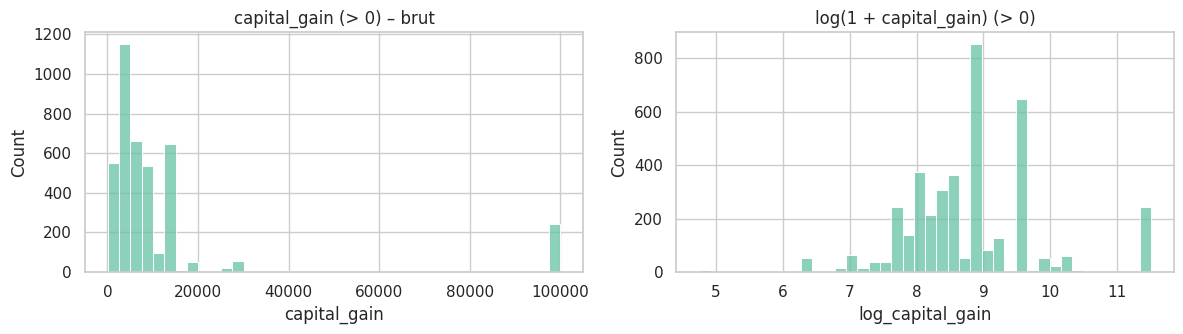

In [84]:
df["log_capital_gain"] = np.log1p(df["capital_gain"])
df["log_capital_loss"] = np.log1p(df["capital_loss"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
sns.histplot(df.loc[df.capital_gain > 0, "capital_gain"], bins=40, ax=axes[0]); axes[0].set_title("capital_gain (> 0) – brut")
sns.histplot(df.loc[df.capital_gain > 0, "log_capital_gain"], bins=40, ax=axes[1]); axes[1].set_title("log(1 + capital_gain) (> 0)")
plt.tight_layout(); plt.show()

- **`capital_gain` / `capital_loss`** : distributions extrêmement asymétriques, avec un plafond à 99 999. La transformation `log(1+x)` réduit l'écart entre 0, quelques milliers et 99 999, sans supprimer de lignes. Les 99 999 sont de vrais revenus élevés codés au plafond : les supprimer biaiserait l'échantillon.
- **`hours_per_week` = 99** et **`age` = 90** : ce sont aussi des plafonds de codage, mais leurs valeurs restent plausibles. On les conserve.

## 4.7 Création de nouvelles variables (feature engineering)

In [85]:
df["capital_net"] = df["capital_gain"] - df["capital_loss"]
df["a_capital"]   = ((df["capital_gain"] > 0) | (df["capital_loss"] > 0)).astype(int)
df["tranche_age"] = pd.cut(df["age"], [16, 25, 35, 45, 55, 65, 91],
                           labels=["17-25", "26-35", "36-45", "46-55", "56-65", "66+"])
df["temps_travail"] = pd.cut(df["hours_per_week"], [0, 34, 45, 99],
                             labels=["Partiel", "Plein", "Surtravail"])
df["cible_aide"] = (df["income"] == "<=50K").astype(int)

df.groupby("temps_travail")["cible_aide"].mean().to_frame("part revenus modestes")

,part revenus modestes
temps_travail,
Partiel,0.931
Plein,0.776
Surtravail,0.584


- `capital_net` : solde du capital. `a_capital` : indicateur binaire « possède des revenus du capital ».
- `tranche_age` et `temps_travail` : versions lisibles pour la description des segments et la présentation.
- `cible_aide` : variable cible binaire (1 = revenu ≤ 50K = bénéficiaire potentiel).

## 4.8 Bilan du nettoyage

In [86]:
bilan = pd.DataFrame({
    "Avant": [n_initial, train_raw.shape[1], int((pd.concat([train_raw, test_raw]) == "?").sum().sum()), 41, 8, 7],
    "Après": [len(df), df.shape[1], int(df.isna().sum().sum()), df.native_country.nunique(),
              df.workclass.nunique(), df.marital_status.nunique()],
}, index=["Lignes", "Colonnes", "Valeurs manquantes", "Modalités native_country",
          "Modalités workclass", "Modalités marital_status"])
bilan

,Avant,Après
Lignes,48842,48790
Colonnes,15,21
Valeurs manquantes,6465,0
Modalités native_country,41,2
Modalités workclass,8,7
Modalités marital_status,7,3


In [87]:
print("Données nettoyées :", df.shape)
df.head()

Données nettoyées : (48790, 21)


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,split,log_capital_gain,log_capital_loss,capital_net,a_capital,tranche_age,temps_travail,cible_aide
0,39,Public_local_etat,13,Celibataire,Adm-clerical,Not-in-family,White,Male,2174,0,40,USA,<=50K,train,7.685,0.000,2174,1,36-45,Plein,1
1,50,Independant_non_societe,13,Marie,Exec-managerial,Husband,White,Male,0,0,13,USA,<=50K,train,0.000,0.000,0,0,46-55,Partiel,1
2,38,Prive,9,Separe_divorce_veuf,Handlers-cleaners,Not-in-family,White,Male,0,0,40,USA,<=50K,train,0.000,0.000,0,0,36-45,Plein,1
3,53,Prive,7,Marie,Handlers-cleaners,Husband,Black,Male,0,0,40,USA,<=50K,train,0.000,0.000,0,0,46-55,Plein,1
4,28,Prive,13,Marie,Prof-specialty,Wife,Black,Female,0,0,40,Autre,<=50K,train,0.000,0.000,0,0,26-35,Plein,1


## 4.9 Encodage et normalisation (données prêtes pour la modélisation)
- **One-Hot Encoding** des variables catégorielles. Elles ne sont pas ordonnées, donc un codage 0/1/2… inventerait un ordre artificiel.
- **Standardisation** des variables numériques (moyenne 0, écart-type 1). C'est indispensable pour K-Means et la régression logistique, qui sont sensibles aux échelles.
- Ces transformations sont **ajustées sur le train uniquement**, puis appliquées au test.

In [88]:
NUM_FEATURES = ["age", "education_num", "hours_per_week", "log_capital_gain", "log_capital_loss"]
CAT_FEATURES = ["workclass", "marital_status", "occupation", "relationship", "race", "sex", "native_country"]
FEATURES = NUM_FEATURES + CAT_FEATURES

def make_preprocess(num=NUM_FEATURES, cat=CAT_FEATURES):
    return ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)])

train = df[df.split == "train"].reset_index(drop=True)
test  = df[df.split == "test"].reset_index(drop=True)

prep = make_preprocess().fit(train[FEATURES])
encoded = pd.DataFrame(prep.transform(df[FEATURES]), columns=prep.get_feature_names_out())
print("Matrice encodée (aperçu, ajustée sur le train) :", encoded.shape)
encoded.head()

Matrice encodée (aperçu, ajustée sur le train) : (48790, 43)


,num__age,num__education_num,num__hours_per_week,num__log_capital_gain,num__log_capital_loss,cat__workclass_Inconnu,cat__workclass_Independant_non_societe,cat__workclass_Independant_societe,cat__workclass_Prive,cat__workclass_Public_federal,cat__workclass_Public_local_etat,cat__workclass_Sans_emploi,cat__marital_status_Celibataire,cat__marital_status_Marie,cat__marital_status_Separe_divorce_veuf,cat__occupation_Adm-clerical,cat__occupation_Craft-repair,cat__occupation_Exec-managerial,cat__occupation_Farming-fishing,cat__occupation_Handlers-cleaners,cat__occupation_Machine-op-inspct,cat__occupation_Never-worked,cat__occupation_Other-service,cat__occupation_Priv-house-serv,cat__occupation_Prof-specialty,cat__occupation_Protective-serv,cat__occupation_Sales,cat__occupation_Tech-support,cat__occupation_Transport-moving,cat__occupation_Unknown,cat__relationship_Husband,cat__relationship_Not-in-family,cat__relationship_Other-relative,cat__relationship_Own-child,cat__relationship_Unmarried,cat__relationship_Wife,cat__race_Autre,cat__race_Black,cat__race_White,cat__sex_Female,cat__sex_Male,cat__native_country_Autre,cat__native_country_USA
0,0.030,1.135,-0.036,2.830,-0.221,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,1.000
1,0.837,1.135,-2.222,-0.299,-0.221,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,1.000
2,-0.043,-0.421,-0.036,-0.299,-0.221,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,1.000
3,1.057,-1.198,-0.036,-0.299,-0.221,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,1.000
4,-0.776,1.135,-0.036,-0.299,-0.221,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000


**Variante pour les modèles à base d'arbres (Gradient Boosting).** Ces modèles ne sont pas sensibles à l'échelle et savent traiter les catégories nativement. On utilise donc un **encodage ordinal** combiné au support natif des variables catégorielles de `HistGradientBoostingClassifier`. Chaque modalité est ainsi traitée comme une catégorie, sans ordre artificiel, et cela évite l'explosion du nombre de colonnes du One-Hot.

In [89]:
def make_preprocess_tree(num=NUM_FEATURES, cat=CAT_FEATURES):
    return ColumnTransformer([
        ("num", "passthrough", num),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat)])

def make_gb(num=NUM_FEATURES, cat=CAT_FEATURES, **params):
    # Pipeline Gradient Boosting avec gestion native des variables catégorielles
    model = HistGradientBoostingClassifier(random_state=RANDOM_STATE,
                                           categorical_features=[False] * len(num) + [True] * len(cat), **params)
    return Pipeline([("prep", make_preprocess_tree(num, cat)), ("model", model)])

Les variables `tranche_age`, `temps_travail`, `capital_net` et `a_capital` ne sont **pas** utilisées par les modèles de classification. Elles dupliquent des informations déjà présentes (âge, heures, capital). Elles servent à décrire les segments.

---
# 5. Segmentation

## 5.1 Objectif et démarche
On cherche des **profils types** dans la population pour concevoir des **politiques différenciées**. La segmentation est **non supervisée** : la cible n'est **pas** utilisée pour construire les groupes. On l'observe seulement *après coup* pour voir quels segments sont les plus vulnérables.

**Méthode : K-Means** sur un ensemble réduit de variables socio-économiques interprétables :
- `age`, `education_num`, `hours_per_week` : position dans le cycle de vie, capital humain, intensité du travail ;
- solde du capital (log signé) : patrimoine ;
- `homme`, `marie`, `celibataire` (indicateurs 0/1) : situation personnelle et familiale.

On limite volontairement le nombre de variables : avec des dizaines de colonnes one-hot, K-Means produit des groupes difficiles à interpréter. Toutes les variables sont standardisées.

In [90]:
seg = pd.DataFrame({
    "age": df["age"],
    "education_num": df["education_num"],
    "hours_per_week": df["hours_per_week"],
    "capital_net_log": np.sign(df["capital_net"]) * np.log1p(df["capital_net"].abs()),
    "homme": (df["sex"] == "Male").astype(int),
    "marie": (df["marital_status"] == "Marie").astype(int),
    "celibataire": (df["marital_status"] == "Celibataire").astype(int),
})
X_seg = StandardScaler().fit_transform(seg)
seg.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
age,38.653,13.708,17.000,90.000
education_num,10.079,2.570,1.000,16.000
hours_per_week,40.426,12.393,1.000,99.000
capital_net_log,0.378,3.003,-8.380,11.513
homme,0.668,0.471,0.000,1.000
marie,0.459,0.498,0.000,1.000
celibataire,0.330,0.470,0.000,1.000


## 5.2 Choix du nombre de segments (méthode du coude + silhouette)

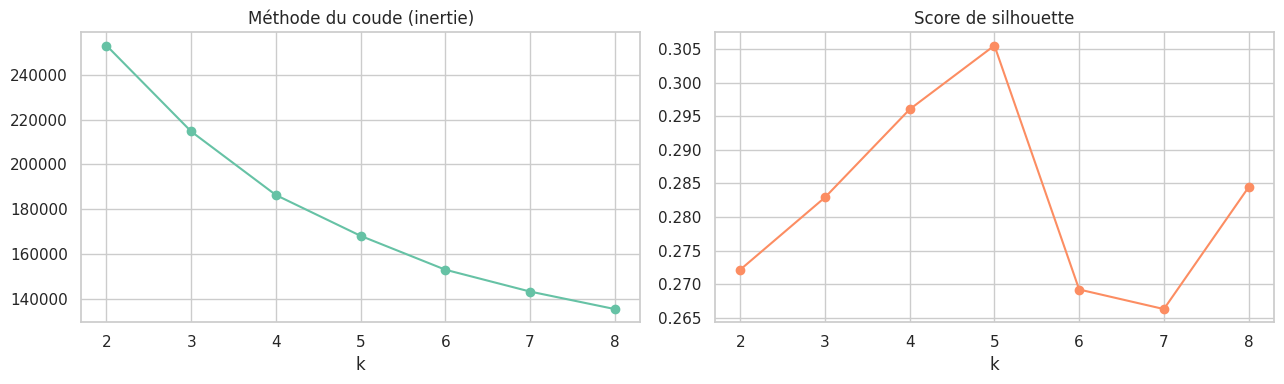

k,2,3,4,5,6,7,8
inertie,"253,111.594","214,692.350","186,293.317","168,053.250","152,926.233","143,165.414","135,339.427"
silhouette,0.272,0.283,0.296,0.306,0.269,0.266,0.284


In [91]:
rng = np.random.RandomState(RANDOM_STATE)
idx_sil = rng.choice(len(X_seg), 8000, replace=False)   # échantillon pour accélérer la silhouette

ks, inerties, silhouettes = range(2, 9), [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_seg)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_seg[idx_sil], km.labels_[idx_sil]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ks, inerties, "o-"); axes[0].set_title("Méthode du coude (inertie)"); axes[0].set_xlabel("k")
axes[1].plot(ks, silhouettes, "o-", color="#fc8d62"); axes[1].set_title("Score de silhouette"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()
pd.DataFrame({"k": list(ks), "inertie": inerties, "silhouette": silhouettes}).set_index("k").T

In [92]:
K = 5
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X_seg)
df["cluster"] = kmeans.labels_

Nous retenons **k = 5** : c'est le **maximum de la silhouette**, et le coude de l'inertie s'atténue à partir de cette valeur. Cinq segments restent aussi un nombre **gérable** pour concevoir des politiques distinctes.

## 5.3 Profil des segments

In [93]:
profil = seg.assign(cluster=df["cluster"], cible_aide=df["cible_aide"]).groupby("cluster").mean()
profil["effectif"] = df["cluster"].value_counts().sort_index()
profil["% population"] = profil["effectif"] / len(df)

def nommer(p):
    # Nom lisible attribué selon les caractéristiques dominantes du segment
    if p["capital_net_log"] > 3:
        return "Detenteurs de capital"
    if p["celibataire"] > 0.5:
        return "Jeunes celibataires - hommes" if p["homme"] > 0.5 else "Jeunes celibataires - femmes"
    if p["homme"] > 0.5:
        return "Hommes en couple, actifs"
    return "Femmes seules (separees, divorcees, veuves)"

noms = profil.apply(nommer, axis=1)
if noms.duplicated().any():   # sécurité si une autre version de scikit-learn donnait d'autres groupes
    noms = noms + " (" + noms.index.astype(str) + ")"
df["segment"] = df["cluster"].map(noms)
profil.index = noms
profil.sort_values("cible_aide", ascending=False)

,age,education_num,hours_per_week,capital_net_log,homme,marie,celibataire,cible_aide,effectif,% population
Jeunes celibataires - femmes,27.435,10.168,34.785,-0.006,0.000,0.000,1.000,0.974,7028,0.144
Jeunes celibataires - hommes,27.749,9.680,38.198,-0.110,1.000,0.000,0.956,0.962,9019,0.185
"Femmes seules (separees, divorcees, veuves)",44.610,9.796,36.758,-0.256,0.022,0.251,0.010,0.864,8591,0.176
"Hommes en couple, actifs",43.568,10.138,44.153,-0.533,0.998,0.856,0.001,0.634,20507,0.420
Detenteurs de capital,45.570,11.226,44.486,8.948,0.809,0.737,0.093,0.320,3645,0.075


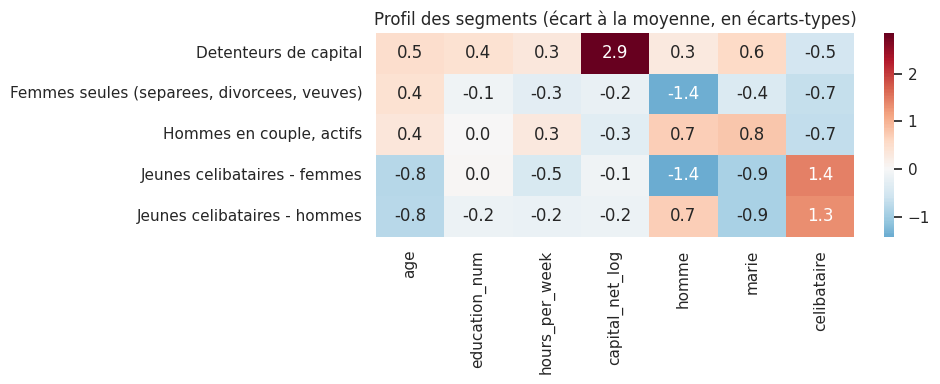

In [94]:
# Heatmap : écart de chaque segment à la moyenne (en écarts-types)
z = pd.DataFrame(X_seg, columns=seg.columns).groupby(df["segment"].values).mean()
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(z, annot=True, fmt=".1f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Profil des segments (écart à la moyenne, en écarts-types)")
plt.tight_layout(); plt.show()

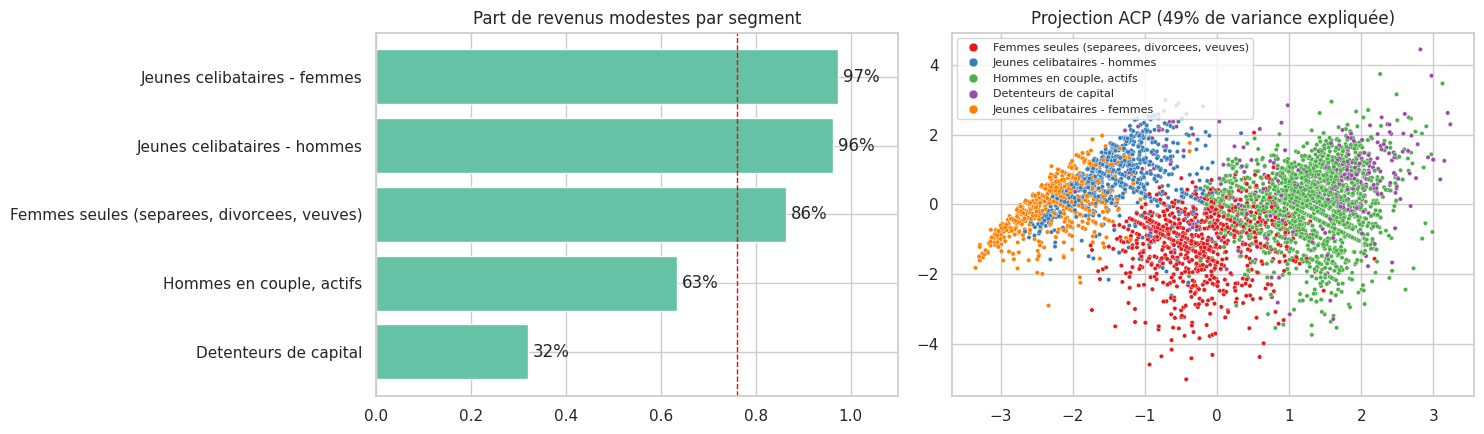

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
t = df.groupby("segment")["cible_aide"].mean().sort_values()
axes[0].barh(t.index, t.values, color="#66c2a5")
axes[0].axvline(df["cible_aide"].mean(), color="red", ls="--", lw=1)
for i, v in enumerate(t.values):
    axes[0].text(v + 0.01, i, f"{v:.0%}", va="center")
axes[0].set_xlim(0, 1.1); axes[0].set_title("Part de revenus modestes par segment")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_seg)
idx = rng.choice(len(coords), 5000, replace=False)
sns.scatterplot(x=coords[idx, 0], y=coords[idx, 1], hue=df["segment"].values[idx], s=10, ax=axes[1], palette="Set1")
axes[1].set_title(f"Projection ACP ({pca.explained_variance_ratio_.sum():.0%} de variance expliquée)")
axes[1].legend(fontsize=8, markerscale=2)
plt.tight_layout(); plt.show()

In [96]:
# Compléments descriptifs : métier dominant, temps de travail, relation dans le foyer
desc = df.groupby("segment").agg(
    metier_principal=("occupation", lambda s: s.value_counts().index[0]),
    relation_principale=("relationship", lambda s: s.value_counts().index[0]),
    part_temps_partiel=("temps_travail", lambda s: (s == "Partiel").mean()),
    part_sans_diplome_secondaire=("education_num", lambda s: (s < 9).mean()),
)
desc

,metier_principal,relation_principale,part_temps_partiel,part_sans_diplome_secondaire
segment,,,,
Detenteurs de capital,Prof-specialty,Husband,0.081,0.064
"Femmes seules (separees, divorcees, veuves)",Adm-clerical,Unmarried,0.248,0.132
"Hommes en couple, actifs",Craft-repair,Husband,0.071,0.126
Jeunes celibataires - femmes,Adm-clerical,Own-child,0.338,0.125
Jeunes celibataires - hommes,Craft-repair,Not-in-family,0.236,0.175


## 5.4 Interprétation : quelles politiques pour quels profils ?
| Segment | Profil | Vulnérabilité | Piste de politique publique |
|---|---|---|---|
| **Jeunes célibataires – femmes** | ≈ 27 ans, temps partiel fréquent, souvent encore « enfant du foyer » | Très forte (≈ 97 % modestes) | Insertion professionnelle, bourses d'études, aide au premier logement |
| **Jeunes célibataires – hommes** | ≈ 28 ans, en début de carrière | Très forte (≈ 96 %) | Formation qualifiante, apprentissage, aide à la mobilité |
| **Femmes seules** (séparées, divorcées, veuves) | ≈ 45 ans, souvent cheffe de famille (*Unmarried*), moins d'heures travaillées (≈ 25 % sont toutefois mariées) | Forte (≈ 86 %) | Aides familiales, garde d'enfants, soutien aux familles monoparentales |
| **Hommes en couple, actifs** | ≈ 44 ans, temps plein | Moyenne (≈ 63 %) : groupe **hétérogène** | Ciblage fin par le diplôme et le métier (crédit d'impôt pour les bas salaires) |
| **Détenteurs de capital** | ≈ 45 ans, plus diplômés, revenus du capital | Faible (≈ 32 %) | Non prioritaire |

La segmentation éclaire le **« pour qui »** et le **« quelle aide »**. Elle ne suffit pas pour décider **individuellement** : le segment « Hommes en couple » mélange des personnes modestes et aisées. D'où la classification, qui suit.

---
# 6. Classification

## 6.1 Démarche
- **Tâche** : prédire `cible_aide` (1 = revenu ≤ 50K) à partir de 12 variables.
- **Découpage** : on conserve le **découpage d'origine** train/test (≈ 2/3 – 1/3), ce qui permet de se comparer aux résultats publiés dans `adult.names`.
- **Réglage des hyperparamètres** : `GridSearchCV` avec **validation croisée stratifiée à 5 plis** sur le train uniquement, en optimisant l'**accuracy**.
- **Choix du modèle final** : celui qui a la meilleure accuracy **en validation croisée**. Le jeu de test n'est utilisé **qu'une seule fois**, pour l'évaluation finale. Choisir le modèle d'après le test serait une forme de triche : le test ne serait plus un juge neutre.
- **Temps d'exécution** : environ 3 à 5 minutes sur Colab pour toute la section.
- **Modèles comparés** :

| Modèle | Intérêt |
|---|---|
| Modèle naïf | Référence minimale (prédit toujours la classe majoritaire) |
| Régression logistique | Très interprétable (odds ratios) |
| Arbre de décision | Règles lisibles |
| Forêt aléatoire | Ensemble d'arbres (bagging), robuste |
| Gradient Boosting | Ensemble d'arbres (boosting), en général le plus performant sur données tabulaires |
| Ensemble (vote) | Moyenne des probabilités des 3 meilleurs modèles |

In [97]:
X_train, y_train = train[FEATURES], train["cible_aide"]
X_test,  y_test  = test[FEATURES],  test["cible_aide"]
print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Part de la classe cible – train : %.3f | test : %.3f" % (y_train.mean(), y_test.mean()))

Train : (32537, 12) | Test : (16253, 12)
Part de la classe cible – train : 0.759 | test : 0.764


## 6.2 Entraînement et réglage des hyperparamètres

In [98]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

import time

def pipe_lin(model, num=NUM_FEATURES, cat=CAT_FEATURES):
    # One-Hot + standardisation : pour les modèles linéaires / arbre simple
    return Pipeline([("prep", make_preprocess(num, cat)), ("model", model)])

def pipe_tree(model, num=NUM_FEATURES, cat=CAT_FEATURES):
    # Encodage ordinal compact : ~5x plus rapide pour la forêt aléatoire
    return Pipeline([("prep", make_preprocess_tree(num, cat)), ("model", model)])

recherches = {
    "Régression logistique": (pipe_lin(LogisticRegression(max_iter=3000)),
                              {"model__C": [0.01, 0.1, 1, 10]}),
    "Arbre de décision": (pipe_lin(DecisionTreeClassifier(random_state=RANDOM_STATE)),
                          {"model__max_depth": [6, 8, 10, 12], "model__min_samples_leaf": [20, 50]}),
    "Forêt aléatoire": (pipe_tree(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
                        {"model__max_features": [0.3, 0.5], "model__min_samples_leaf": [2, 5]}),
    "Gradient Boosting": (make_gb(max_iter=500, l2_regularization=1.0),
                          {"model__learning_rate": [0.05, 0.1], "model__max_leaf_nodes": [15, 31],
                           "model__min_samples_leaf": [20, 40]}),
}

best_models, best_params, cv_acc = {}, {}, {}
for nom, (pipe, grille) in recherches.items():
    t0 = time.time()
    gs = GridSearchCV(pipe, grille, cv=cv, scoring="accuracy", n_jobs=-1).fit(X_train, y_train)
    best_models[nom], best_params[nom], cv_acc[nom] = gs.best_estimator_, gs.best_params_, gs.best_score_
    print(f"{nom:24s} accuracy CV = {gs.best_score_:.4f} | {gs.best_params_} | {time.time() - t0:.0f} s", flush=True)

Régression logistique    accuracy CV = 0.8441 | {'model__C': 0.1} | 8 s
Arbre de décision        accuracy CV = 0.8567 | {'model__max_depth': 12, 'model__min_samples_leaf': 20} | 7 s
Forêt aléatoire          accuracy CV = 0.8659 | {'model__max_features': 0.3, 'model__min_samples_leaf': 5} | 113 s
Gradient Boosting        accuracy CV = 0.8726 | {'model__learning_rate': 0.05, 'model__max_leaf_nodes': 15, 'model__min_samples_leaf': 40} | 58 s


In [42]:
# Modèle naïf (référence) et ensemble par vote "soft" des trois meilleurs modèles
best_models["Modèle naïf"] = pipe_lin(DummyClassifier(strategy="most_frequent")).fit(X_train, y_train)
vote = VotingClassifier([("lr", clone(best_models["Régression logistique"])),
                         ("rf", clone(best_models["Forêt aléatoire"])),
                         ("gb", clone(best_models["Gradient Boosting"]))], voting="soft")
t0 = time.time()
cv_acc["Ensemble (vote)"] = cross_validate(vote, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)["test_score"].mean()
best_models["Ensemble (vote)"] = vote.fit(X_train, y_train)
print(f"{'Ensemble (vote)':24s} accuracy CV = {cv_acc['Ensemble (vote)']:.4f} | {time.time() - t0:.0f} s")
cv_acc["Modèle naïf"] = (y_train == 1).mean()

# Le modèle final est choisi sur la VALIDATION CROISÉE (et non sur le test, qui reste un juge neutre)
MEILLEUR = max(cv_acc, key=cv_acc.get)
print(f"\nModèle retenu (meilleure accuracy en validation croisée) : {MEILLEUR}")

Ensemble (vote)          accuracy CV = 0.8689 | 42 s

Modèle retenu (meilleure accuracy en validation croisée) : Gradient Boosting


## 6.3 Évaluation complète sur le jeu de test

| Métrique | Ce qu'elle mesure |
|---|---|
| **Accuracy** | Part de prédictions correctes |
| **Balanced accuracy** | Moyenne des rappels des deux classes (corrige le déséquilibre) |
| **Précision (cible)** | Parmi les personnes sélectionnées pour l'aide, part réellement modeste |
| **Rappel / sensibilité (cible)** | Parmi les personnes modestes, part détectée (= 1 − taux d'exclusion) |
| **Spécificité** | Parmi les personnes aisées, part correctement écartée (= 1 − taux d'inclusion) |
| **F1 (cible), F1 macro, F1 pondéré** | Compromis précision / rappel (pour la cible, moyenne simple des 2 classes, moyenne pondérée) |
| **ROC-AUC** | Capacité à classer un modeste avant un aisé, indépendamment du seuil |
| **PR-AUC** | Aire sous la courbe précision-rappel |
| **Log loss, score de Brier** | Qualité des probabilités (plus bas = mieux) |
| **MCC, Kappa de Cohen** | Accord prédiction / réalité corrigé du hasard, robuste au déséquilibre |
| **Taux d'exclusion / d'inclusion** | Indicateurs métier (voir Business Understanding) |

In [43]:
def evaluer(y, proba, seuil=0.5):
    y = np.asarray(y)
    pred = (proba >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "Accuracy": accuracy_score(y, pred),
        "Balanced accuracy": balanced_accuracy_score(y, pred),
        "Précision (cible)": precision_score(y, pred, zero_division=0),
        "Rappel (cible)": recall_score(y, pred),
        "Spécificité": tn / (tn + fp),
        "F1 (cible)": f1_score(y, pred),
        "F1 macro": f1_score(y, pred, average="macro"),
        "F1 pondéré": f1_score(y, pred, average="weighted"),
        "ROC-AUC": roc_auc_score(y, proba),
        "PR-AUC": average_precision_score(y, proba),
        "Log loss": log_loss(y, np.clip(proba, 1e-6, 1 - 1e-6)),
        "Brier": brier_score_loss(y, proba),
        "MCC": matthews_corrcoef(y, pred),
        "Kappa": cohen_kappa_score(y, pred),
        "Taux d'exclusion": fn / (fn + tp),
        "Taux d'inclusion": fp / (fp + tn),
    }

probas = {nom: m.predict_proba(X_test)[:, 1] for nom, m in best_models.items()}
resultats = pd.DataFrame({nom: evaluer(y_test, p) for nom, p in probas.items()}).T
resultats.insert(0, "Accuracy CV (train)", pd.Series(cv_acc))
resultats = resultats.sort_values("Accuracy CV (train)", ascending=False)

plus_bas_mieux = ["Log loss", "Brier", "Taux d'exclusion", "Taux d'inclusion"]
plus_haut_mieux = [c for c in resultats.columns if c not in plus_bas_mieux]
(resultats.style.format("{:.4f}")
    .highlight_max(subset=plus_haut_mieux, color="#b7e4c7")
    .highlight_min(subset=plus_bas_mieux, color="#b7e4c7"))

,Accuracy CV (train),Accuracy,Balanced accuracy,Précision (cible),Rappel (cible),Spécificité,F1 (cible),F1 macro,F1 pondéré,ROC-AUC,PR-AUC,Log loss,Brier,MCC,Kappa,Taux d'exclusion,Taux d'inclusion
Gradient Boosting,0.8726,0.8733,0.7974,0.8977,0.9414,0.6533,0.9190,0.8141,0.8694,0.9266,0.9752,0.2780,0.0882,0.6327,0.6289,0.0586,0.3467
Ensemble (vote),0.8689,0.8711,0.7887,0.8925,0.9450,0.6325,0.9180,0.8084,0.8662,0.9203,0.9730,0.2927,0.0922,0.6235,0.6179,0.0550,0.3675
Forêt aléatoire,0.8659,0.8651,0.7766,0.8863,0.9444,0.6088,0.9145,0.7976,0.8592,0.9166,0.9717,0.2965,0.0939,0.6036,0.5968,0.0556,0.3912
Arbre de décision,0.8567,0.8585,0.7492,0.8709,0.9565,0.5419,0.9117,0.7779,0.8484,0.9040,0.9616,0.3467,0.0981,0.5757,0.5598,0.0435,0.4581
Régression logistique,0.8441,0.8476,0.7580,0.8792,0.9280,0.5880,0.9029,0.7744,0.8421,0.8990,0.9666,0.3293,0.1057,0.5544,0.5500,0.0720,0.4120
Modèle naïf,0.7591,0.7636,0.5000,0.7636,1.0000,0.0000,0.8660,0.4330,0.6613,0.5000,0.7636,3.2658,0.2364,0.0000,0.0000,0.0000,1.0000


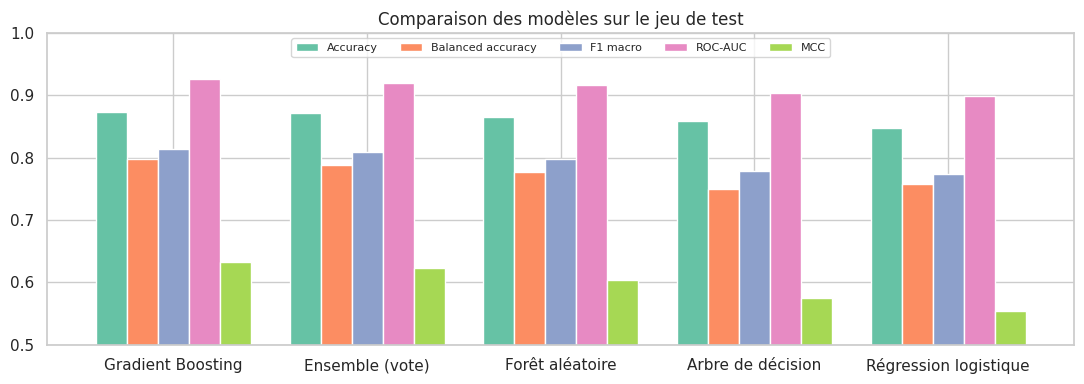

Modèle retenu : Gradient Boosting – accuracy CV = 0.8726 | accuracy test = 0.8733


In [44]:
fig, ax = plt.subplots(figsize=(11, 4))
cols_graph = ["Accuracy", "Balanced accuracy", "F1 macro", "ROC-AUC", "MCC"]
resultats.drop(index="Modèle naïf")[cols_graph].plot.bar(ax=ax, rot=0, width=0.8)
ax.set_ylim(0.5, 1); ax.set_title("Comparaison des modèles sur le jeu de test")
ax.legend(ncol=5, loc="upper center", fontsize=8)
plt.tight_layout(); plt.show()

print(f"Modèle retenu : {MEILLEUR} – accuracy CV = {cv_acc[MEILLEUR]:.4f} | accuracy test = {resultats.loc[MEILLEUR, 'Accuracy']:.4f}")

**Lecture :**
- Le **modèle naïf** atteint environ 76 % d'accuracy sans rien apprendre. Son MCC est nul et son **taux d'inclusion de 100 %** : il donne l'aide à tout le monde. C'est la preuve que l'accuracy seule ne suffit pas.
- Le **Gradient Boosting** est le meilleur modèle sur presque toutes les métriques : **87,3 % d'accuracy** sur le test (87,3 % en validation croisée, donc aucun sur-apprentissage), ROC-AUC de **0,927** et MCC de 0,63.
- L'**ensemble par vote** ne fait **pas mieux** que le Gradient Boosting seul : moyenner avec des modèles plus faibles dilue sa performance. On garde donc le modèle le plus simple des deux.
- Ces scores dépassent les scores de référence de `adult.names` (C4.5 : 84,5 %, NBTree : 85,9 %), qui ont pourtant été obtenus **après suppression** des lignes incomplètes, alors que nous les gardons toutes.
- La **régression logistique** perd environ 2,5 points d'accuracy, mais reste **totalement transparente**.
- Les écarts entre les meilleurs modèles sont faibles : sur ce dataset, environ 87–88 % est le plafond connu, quelle que soit la méthode.

---
# 7. Évaluation et interprétation des résultats

## 7.1 Rapport de classification et matrices de confusion

In [45]:
print(f"=== Rapport de classification – {MEILLEUR} (seuil 0,5) ===\n")
print(classification_report(y_test, (probas[MEILLEUR] >= 0.5).astype(int),
                            target_names=["Aisé (>50K)", "Modeste (≤50K)"], digits=4))

=== Rapport de classification – Gradient Boosting (seuil 0,5) ===

                precision    recall  f1-score   support

   Aisé (>50K)     0.7754    0.6533    0.7091      3842
Modeste (≤50K)     0.8977    0.9414    0.9190     12411

      accuracy                         0.8733     16253
     macro avg     0.8365    0.7974    0.8141     16253
  weighted avg     0.8688    0.8733    0.8694     16253



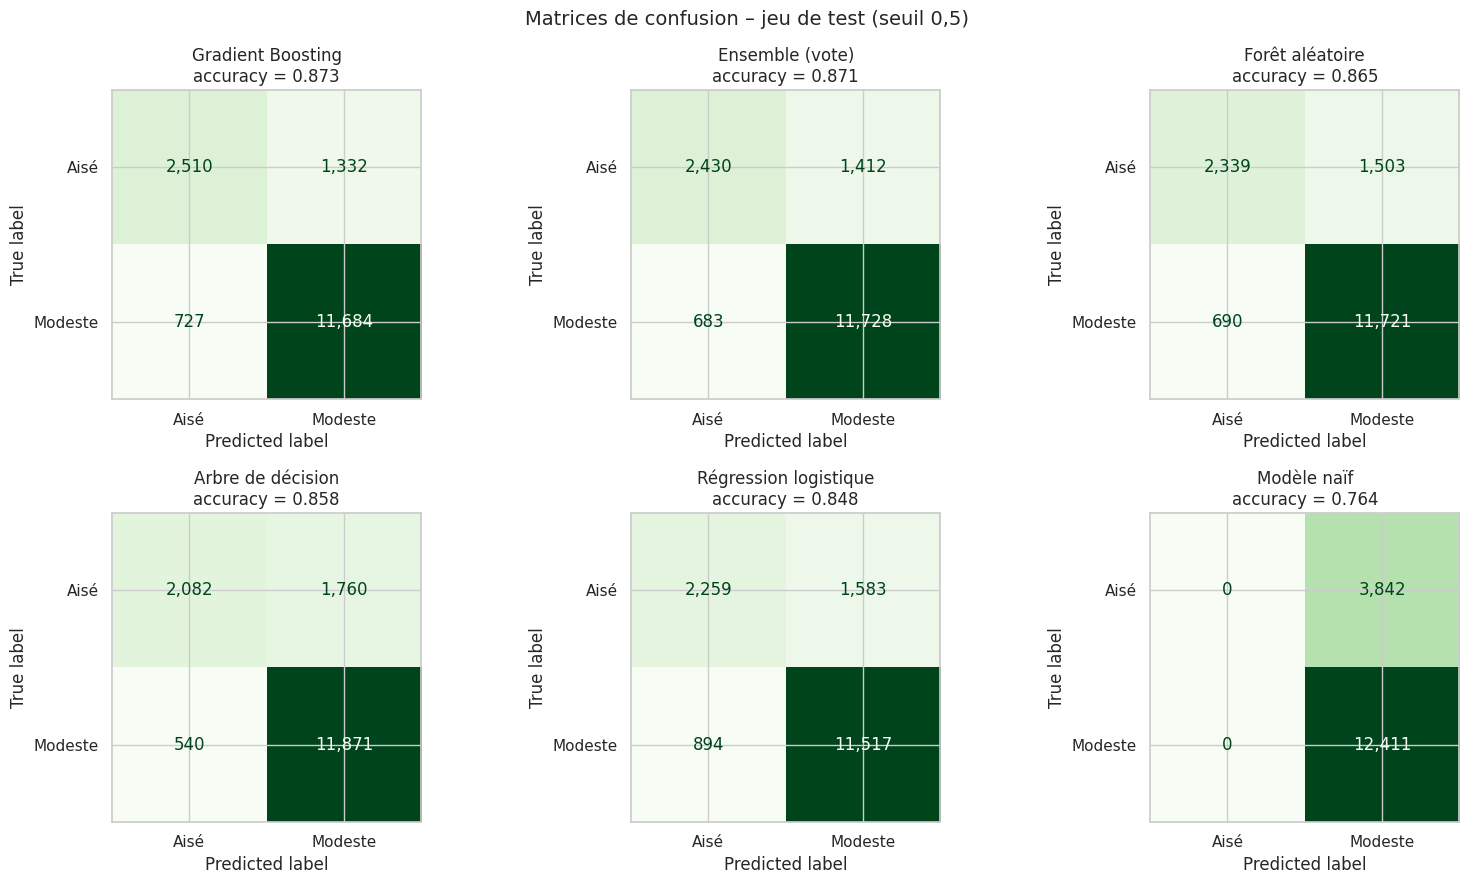

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, nom in zip(axes.ravel(), resultats.index):
    ConfusionMatrixDisplay.from_predictions(y_test, (probas[nom] >= 0.5).astype(int),
        display_labels=["Aisé", "Modeste"], cmap="Greens", ax=ax, values_format=",", colorbar=False)
    ax.set_title(f"{nom}\naccuracy = {resultats.loc[nom, 'Accuracy']:.3f}")
plt.suptitle("Matrices de confusion – jeu de test (seuil 0,5)", fontsize=14)
plt.tight_layout(); plt.show()

## 7.2 Courbes ROC et précision-rappel

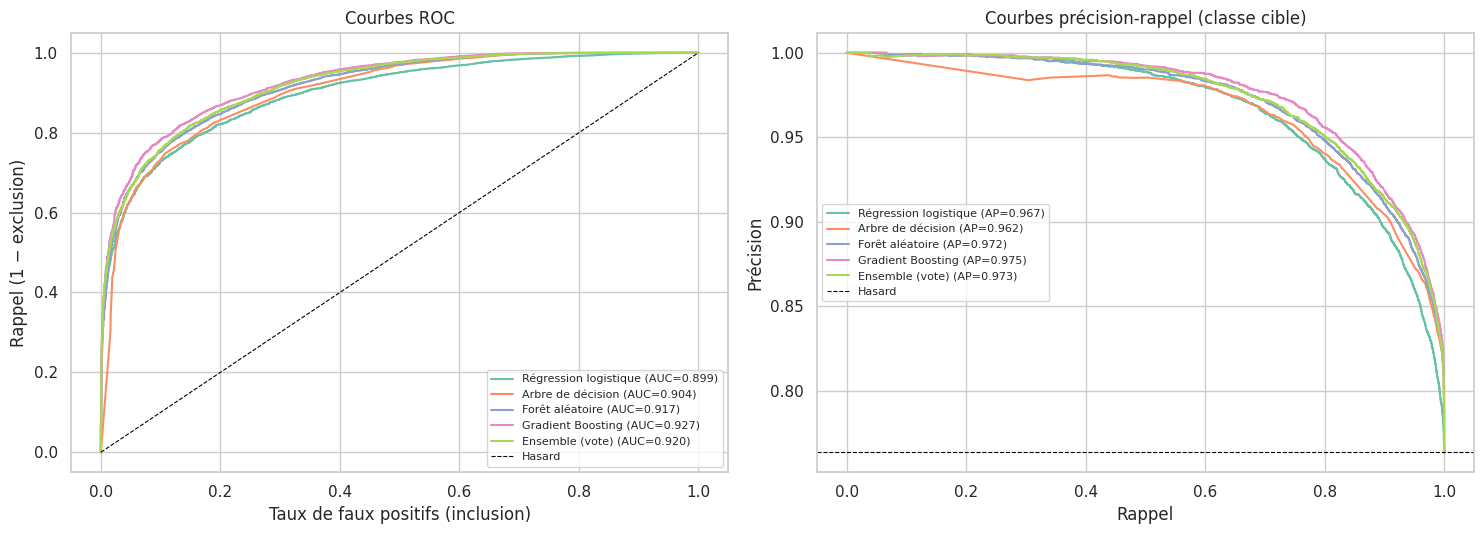

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for nom, p in probas.items():
    if nom == "Modèle naïf":
        continue
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{nom} (AUC={roc_auc_score(y_test, p):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, label=f"{nom} (AP={average_precision_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="Hasard")
axes[0].set_xlabel("Taux de faux positifs (inclusion)"); axes[0].set_ylabel("Rappel (1 − exclusion)")
axes[0].set_title("Courbes ROC"); axes[0].legend(fontsize=8)
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=0.8, label="Hasard")
axes[1].set_xlabel("Rappel"); axes[1].set_ylabel("Précision")
axes[1].set_title("Courbes précision-rappel (classe cible)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7.3 Stabilité du meilleur modèle (validation croisée à 5 plis)
Un bon score sur un seul jeu de test peut être dû à la chance. On vérifie que les performances sont **stables** d'un pli à l'autre sur le train.

In [48]:
scores_cv = cross_validate(clone(best_models[MEILLEUR]), X_train, y_train, cv=cv, n_jobs=-1,
                           scoring=["accuracy", "balanced_accuracy", "precision", "recall", "f1", "f1_macro", "roc_auc"])
stab = pd.DataFrame({k.replace("test_", ""): v for k, v in scores_cv.items() if k.startswith("test_")})
stab.index = [f"Pli {i+1}" for i in range(len(stab))]
stab.loc["Moyenne"] = stab.mean()
stab.loc["Écart-type"] = stab.iloc[:5].std()
stab.style.format("{:.4f}")

,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,roc_auc
Pli 1,0.8729,0.8007,0.8974,0.9401,0.9182,0.8166,0.9270
Pli 2,0.8720,0.8003,0.8974,0.9387,0.9176,0.8156,0.9307
Pli 3,0.8723,0.7952,0.8938,0.9439,0.9182,0.8137,0.9301
Pli 4,0.8746,0.7986,0.8953,0.9453,0.9196,0.8172,0.9281
Pli 5,0.8711,0.8004,0.8977,0.9368,0.9169,0.8148,0.9268
Moyenne,0.8726,0.7990,0.8963,0.9410,0.9181,0.8156,0.9285
Écart-type,0.0013,0.0023,0.0017,0.0036,0.0010,0.0014,0.0018


Les écarts-types sont très faibles (moins de 0,3 point) et la moyenne en validation croisée est proche du score sur le test. Le modèle **généralise bien** et ne sur-apprend pas.

## 7.4 Calibration des probabilités
Si le modèle annonce une probabilité de 0,8 d'être modeste, on veut qu'environ 80 % de ces personnes le soient réellement. C'est important si la probabilité sert à **prioriser** les dossiers.

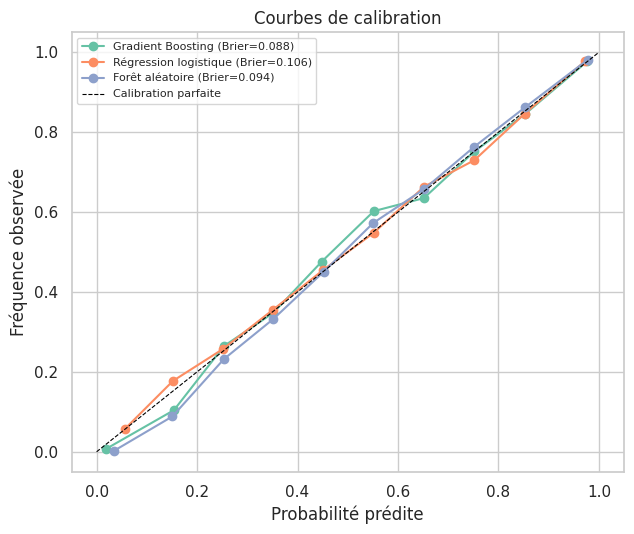

In [49]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for nom in [MEILLEUR, "Régression logistique", "Forêt aléatoire"]:
    frac, moy = calibration_curve(y_test, probas[nom], n_bins=10)
    ax.plot(moy, frac, "o-", label=f"{nom} (Brier={brier_score_loss(y_test, probas[nom]):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Calibration parfaite")
ax.set_xlabel("Probabilité prédite"); ax.set_ylabel("Fréquence observée")
ax.set_title("Courbes de calibration"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7.5 Choix du seuil de décision
Le seuil 0,5 n'a rien d'obligatoire. On compare trois options, avec des seuils choisis **sur des prédictions de validation croisée du train**, pour ne pas « tricher » avec le test :
1. **Seuil 0,5** (par défaut) ;
2. **Seuil qui maximise l'accuracy** ;
3. **Seuil « social »**, qui minimise un coût où l'exclusion compte **double** :
$$\text{Coût} = 2 \times \text{(modestes exclus)} + 1 \times \text{(aisés inclus)}$$

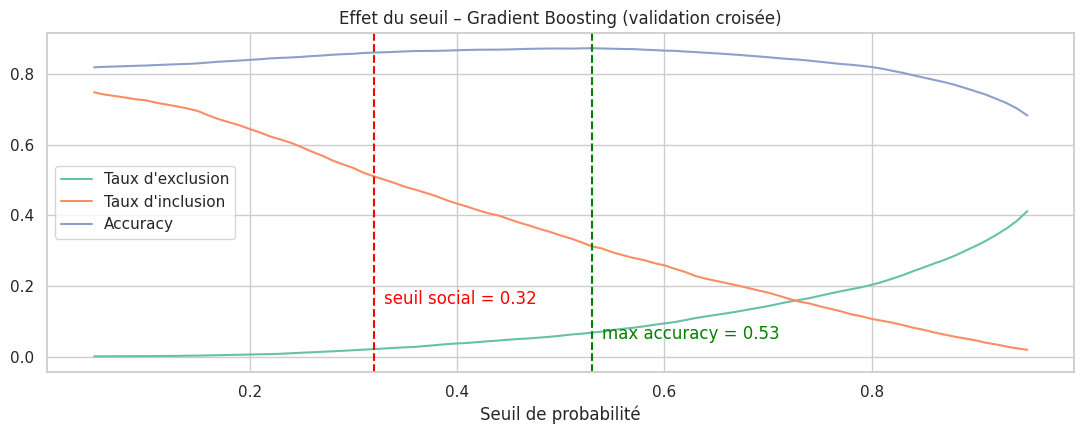

,Accuracy,Balanced accuracy,Précision (cible),Rappel (cible),F1 macro,MCC,Taux d'exclusion,Taux d'inclusion
"Seuil 0,5",0.8733,0.7974,0.8977,0.9414,0.8141,0.6327,0.0586,0.3467
Max accuracy (0.53),0.8718,0.8040,0.9027,0.9326,0.8155,0.6331,0.0674,0.3246
Seuil social (0.32),0.8624,0.7315,0.8596,0.9799,0.7699,0.5857,0.0201,0.5169


In [50]:
proba_cv = cross_val_predict(clone(best_models[MEILLEUR]), X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

seuils = np.round(np.arange(0.05, 0.96, 0.01), 2)
courbe = pd.DataFrame([evaluer(y_train, proba_cv, s) for s in seuils], index=seuils)
n_mod, n_ais = y_train.sum(), (1 - y_train).sum()
courbe["Coût social"] = 2 * courbe["Taux d'exclusion"] * n_mod + courbe["Taux d'inclusion"] * n_ais
SEUIL_ACC = courbe["Accuracy"].idxmax()
SEUIL = courbe["Coût social"].idxmin()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(courbe.index, courbe["Taux d'exclusion"], label="Taux d'exclusion")
ax.plot(courbe.index, courbe["Taux d'inclusion"], label="Taux d'inclusion")
ax.plot(courbe.index, courbe["Accuracy"], label="Accuracy")
ax.axvline(SEUIL_ACC, color="green", ls="--"); ax.text(SEUIL_ACC + 0.01, 0.05, f"max accuracy = {SEUIL_ACC}", color="green")
ax.axvline(SEUIL, color="red", ls="--"); ax.text(SEUIL + 0.01, 0.15, f"seuil social = {SEUIL}", color="red")
ax.set_xlabel("Seuil de probabilité"); ax.set_title(f"Effet du seuil – {MEILLEUR} (validation croisée)")
ax.legend(); plt.tight_layout(); plt.show()

comparaison_seuils = pd.DataFrame({
    "Seuil 0,5": evaluer(y_test, probas[MEILLEUR], 0.5),
    f"Max accuracy ({SEUIL_ACC})": evaluer(y_test, probas[MEILLEUR], SEUIL_ACC),
    f"Seuil social ({SEUIL})": evaluer(y_test, probas[MEILLEUR], SEUIL),
}).T
comparaison_seuils[["Accuracy", "Balanced accuracy", "Précision (cible)", "Rappel (cible)",
                    "F1 macro", "MCC", "Taux d'exclusion", "Taux d'inclusion"]].style.format("{:.4f}")

**Lecture :**
- Le seuil qui maximise l'accuracy en validation croisée (≈ 0,53) est **très proche de 0,5**, et il n'améliore pas l'accuracy sur le test. Le modèle est bien calibré : le seuil par défaut de 0,5 est déjà le bon choix pour maximiser l'accuracy.
- Le **seuil social** est plus bas. Il **divise par plus de deux le taux d'exclusion** (≈ 6 % → ≈ 2 %), au prix d'un taux d'inclusion plus élevé (≈ 35 % → ≈ 52 %). La précision reste élevée : environ 86 % des personnes sélectionnées sont réellement modestes.
- Le choix du seuil est une **décision politique**. Avec un budget contraint, on remonte le seuil pour limiter les fuites. Avec une priorité d'accès aux droits, on le baisse.

## 7.6 Quelles variables pèsent le plus ? (importance par permutation)
On mélange aléatoirement une variable et on mesure la perte d'accuracy. Plus la perte est forte, plus le modèle dépend de cette variable.

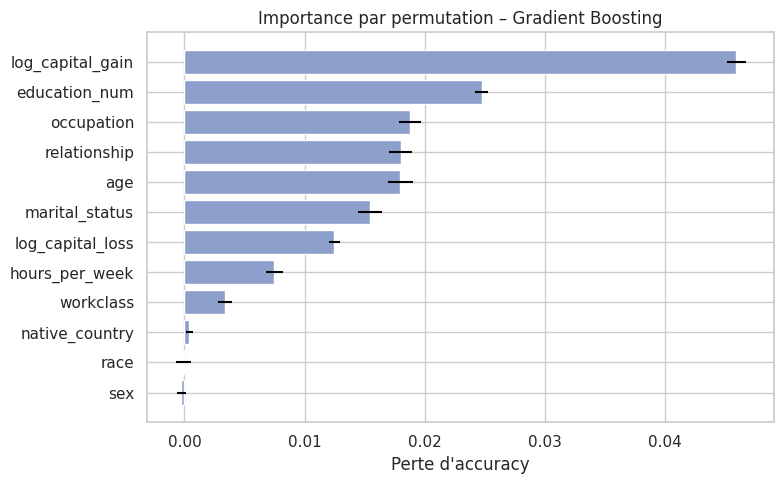

In [51]:
perm = permutation_importance(best_models[MEILLEUR], X_test, y_test, scoring="accuracy",
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
ordre = np.argsort(perm.importances_mean)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(np.array(FEATURES)[ordre], perm.importances_mean[ordre], xerr=perm.importances_std[ordre], color="#8da0cb")
ax.set_title(f"Importance par permutation – {MEILLEUR}"); ax.set_xlabel("Perte d'accuracy")
plt.tight_layout(); plt.show()

**Lecture :**
- Les **plus-values** dominent nettement. Viennent ensuite le **niveau d'éducation**, le **métier**, la situation familiale (`relationship` et `marital_status`), l'**âge**, puis les moins-values, le temps de travail et le type d'employeur.
- `workclass` a désormais un poids réel, grâce au regroupement plus fin (indépendants en société / hors société, public fédéral).
- La situation familiale est répartie entre **deux variables redondantes** : quand on en mélange une, l'autre compense. Son importance réelle est donc sous-estimée ici. Dans l'exploration, c'était l'un des facteurs les plus forts.
- **Le sexe, l'origine et le pays ont un poids nul.**

## 7.7 Interprétation avec la régression logistique (odds ratios)
Un coefficient **positif** augmente la probabilité d'être **modeste**. L'*odds ratio* = exp(coefficient) multiplie la cote : un odds ratio de 2 signifie une cote « modeste » deux fois plus élevée.

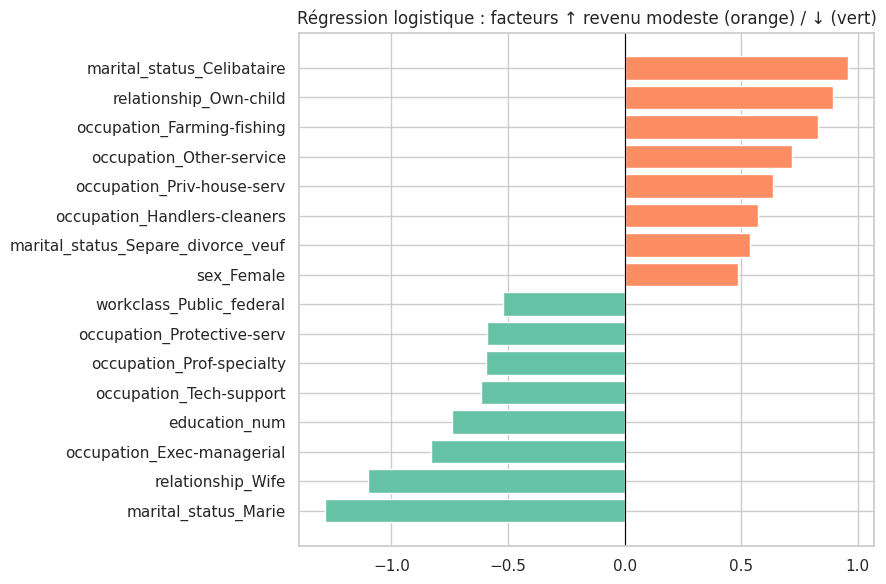

,coefficient,odds ratio
marital_status_Celibataire,0.957,2.605
relationship_Own-child,0.895,2.447
occupation_Farming-fishing,0.830,2.293
occupation_Other-service,0.719,2.053
occupation_Priv-house-serv,0.638,1.892
occupation_Handlers-cleaners,0.572,1.772
marital_status_Separe_divorce_veuf,0.537,1.711
sex_Female,0.485,1.623
workclass_Public_federal,-0.521,0.594
occupation_Protective-serv,-0.588,0.555


In [52]:
lr = best_models["Régression logistique"]
coefs = pd.Series(lr.named_steps["model"].coef_[0], index=lr.named_steps["prep"].get_feature_names_out())
coefs.index = coefs.index.str.replace("num__", "").str.replace("cat__", "")
top = pd.concat([coefs.nsmallest(8), coefs.nlargest(8)]).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top.values, color=np.where(top.values > 0, "#fc8d62", "#66c2a5"))
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Régression logistique : facteurs ↑ revenu modeste (orange) / ↓ (vert)")
plt.tight_layout(); plt.show()
pd.DataFrame({"coefficient": top, "odds ratio": np.exp(top)}).sort_values("coefficient", ascending=False)

**Lecture :**
- Les facteurs qui **augmentent** la probabilité d'un revenu modeste sont : les métiers agricoles, de service et de manutention, être célibataire, séparé, divorcé ou veuf, et vivre comme enfant ou parent dans le foyer.
- Les facteurs **protecteurs** sont : être marié, occuper un poste de cadre ou une profession intellectuelle, avoir un diplôme élevé et des plus-values.
- Ces résultats sont cohérents avec l'exploration et l'importance par permutation.

## 7.8 Des règles lisibles pour un agent administratif (arbre de profondeur 3)

Arbre simple – accuracy test : 0.845 | ROC-AUC : 0.862


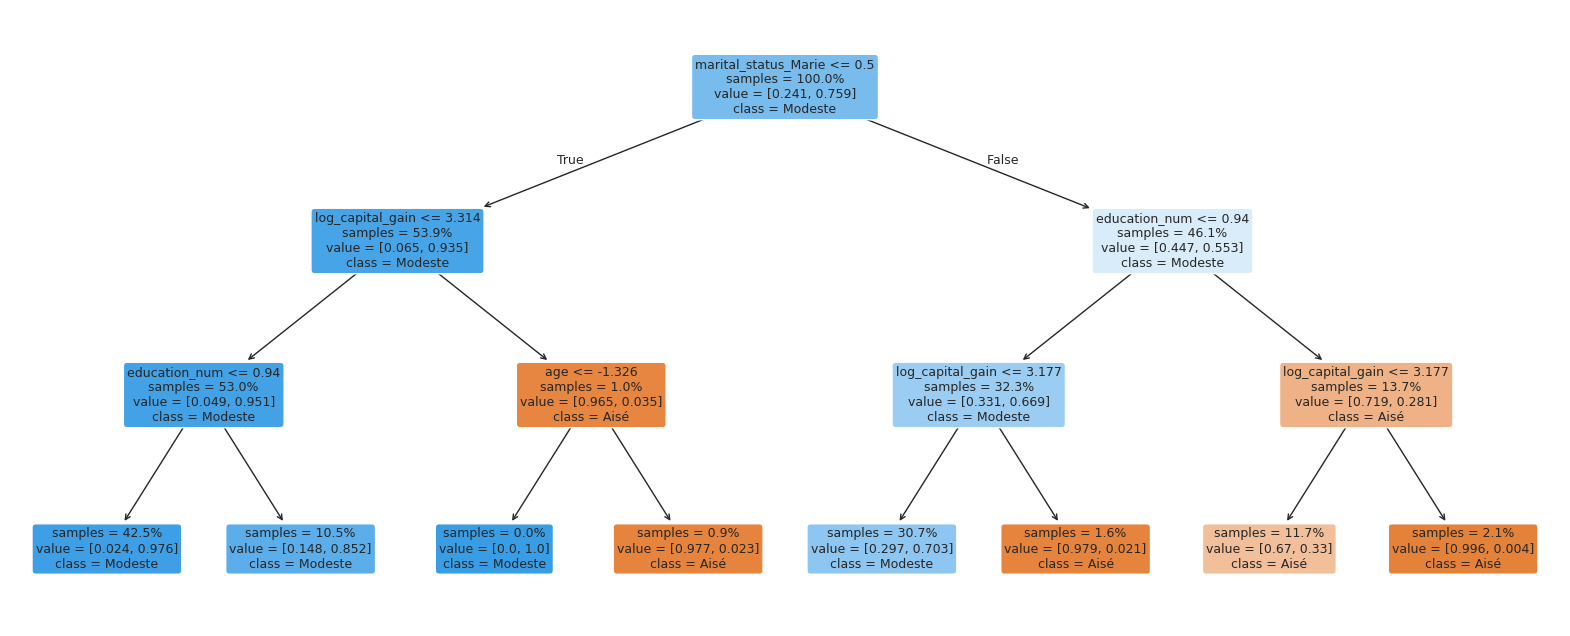

Pour reconvertir les seuils standardisés : valeur réelle = seuil × écart-type + moyenne


,moyenne,écart-type
age,38.586,13.638
education_num,10.082,2.572
hours_per_week,40.440,12.347
log_capital_gain,0.735,2.456
log_capital_loss,0.351,1.585


In [53]:
arbre = pipe_lin(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)).fit(X_train, y_train)
print(f"Arbre simple – accuracy test : {accuracy_score(y_test, arbre.predict(X_test)):.3f} | "
      f"ROC-AUC : {roc_auc_score(y_test, arbre.predict_proba(X_test)[:, 1]):.3f}")
fig, ax = plt.subplots(figsize=(20, 8))
noms_var = [n.replace("num__", "").replace("cat__", "") for n in arbre.named_steps["prep"].get_feature_names_out()]
plot_tree(arbre.named_steps["model"], feature_names=noms_var, class_names=["Aisé", "Modeste"],
          filled=True, rounded=True, fontsize=9, impurity=False, proportion=True, ax=ax)
plt.show()

scaler = arbre.named_steps["prep"].named_transformers_["num"]
print("Pour reconvertir les seuils standardisés : valeur réelle = seuil × écart-type + moyenne")
pd.DataFrame({"moyenne": scaler.mean_, "écart-type": scaler.scale_}, index=NUM_FEATURES)

Seulement 3 questions permettent déjà d'atteindre environ 84,5 % d'accuracy. On perd quelques points par rapport au meilleur modèle, mais on gagne une **transparence totale** pour expliquer une décision à un citoyen.

## 7.9 Analyse d'équité
Un outil de ciblage public ne doit pas commettre **plus d'erreurs** pour certains groupes protégés. On compare les taux d'erreur par sexe et par origine, avec le seuil social.

In [54]:
def equite(proba, seuil, groupe):
    lignes = {}
    for g in test[groupe].unique():
        m = (test[groupe] == g).values
        r = evaluer(y_test[m], proba[m], seuil)
        lignes[g] = {"Effectif": int(m.sum()), "Accuracy": r["Accuracy"], "Taux d'exclusion": r["Taux d'exclusion"],
                     "Taux d'inclusion": r["Taux d'inclusion"], "Part sélectionnée": (proba[m] >= seuil).mean(),
                     "Part réellement modeste": y_test[m].mean()}
    return pd.DataFrame(lignes).T

print("=== Par sexe ===");    display(equite(probas[MEILLEUR], SEUIL, "sex"))
print("=== Par origine ==="); display(equite(probas[MEILLEUR], SEUIL, "race"))

=== Par sexe ===


,Effectif,Accuracy,Taux d'exclusion,Taux d'inclusion,Part sélectionnée,Part réellement modeste
Male,"10,839.000",0.827,0.029,0.510,0.833,0.700
Female,"5,414.000",0.934,0.007,0.556,0.946,0.891


=== Par origine ===


,Effectif,Accuracy,Taux d'exclusion,Taux d'inclusion,Part sélectionnée,Part réellement modeste
Black,"1,561.000",0.926,0.007,0.592,0.947,0.885
White,"13,919.000",0.856,0.022,0.511,0.861,0.750
Autre,773.000,0.855,0.023,0.554,0.880,0.771


**Test : retirer les variables sensibles.** On ré-entraîne le même modèle **sans `sex`, `race` ni `native_country`**, avec les mêmes hyperparamètres. Attention : `relationship` (Husband/Wife) reste un **proxy** du sexe.

In [55]:
CAT_SS = ["workclass", "marital_status", "occupation", "relationship"]
FEAT_SS = NUM_FEATURES + CAT_SS

def construire(nom, num, cat):
    # Reconstruit un modèle avec les mêmes hyperparamètres mais d'autres variables
    gb_params = {k.replace("model__", ""): v for k, v in best_params["Gradient Boosting"].items()}
    if nom == "Gradient Boosting":
        return make_gb(num, cat, max_iter=500, l2_regularization=1.0, **gb_params)
    if nom == "Ensemble (vote)":
        return VotingClassifier([
            ("lr", pipe_lin(clone(best_models["Régression logistique"].named_steps["model"]), num, cat)),
            ("rf", pipe_tree(clone(best_models["Forêt aléatoire"].named_steps["model"]), num, cat)),
            ("gb", make_gb(num, cat, max_iter=500, l2_regularization=1.0, **gb_params))], voting="soft")
    if nom == "Forêt aléatoire":
        return pipe_tree(clone(best_models[nom].named_steps["model"]), num, cat)
    return pipe_lin(clone(best_models[nom].named_steps["model"]), num, cat)

modele_ss = construire(MEILLEUR, NUM_FEATURES, CAT_SS).fit(train[FEAT_SS], y_train)
proba_ss = modele_ss.predict_proba(test[FEAT_SS])[:, 1]

cols_eq = ["Accuracy", "ROC-AUC", "F1 macro", "Taux d'exclusion", "Taux d'inclusion"]
display(pd.DataFrame({"Avec variables sensibles": evaluer(y_test, probas[MEILLEUR], SEUIL),
                      "Sans variables sensibles": evaluer(y_test, proba_ss, SEUIL)}).T[cols_eq])
print("=== Sans variables sensibles – par sexe ===")
display(equite(proba_ss, SEUIL, "sex"))

,Accuracy,ROC-AUC,F1 macro,Taux d'exclusion,Taux d'inclusion
Avec variables sensibles,0.862,0.927,0.770,0.020,0.517
Sans variables sensibles,0.862,0.927,0.770,0.021,0.516


=== Sans variables sensibles – par sexe ===


,Effectif,Accuracy,Taux d'exclusion,Taux d'inclusion,Part sélectionnée,Part réellement modeste
Male,"10,839.000",0.826,0.029,0.511,0.833,0.700
Female,"5,414.000",0.934,0.008,0.541,0.943,0.891


**Lecture :**
- Les erreurs ne sont **pas réparties de la même façon**. Les femmes et les personnes noires sont rarement exclues à tort, mais plus souvent **incluses** à tort. Le modèle les associe aux revenus modestes, ce qui reflète les inégalités réelles des données de 1994.
- Sans `sex`, `race` ni `native_country`, la performance est **quasiment identique** et les écarts entre groupes ne changent presque pas. Le modèle retrouve l'information par des **variables proxy** (situation familiale, métier, heures).
- Retirer une variable sensible ne garantit donc pas l'équité : il faut **mesurer** les écarts. On peut quand même retirer ces variables pour des raisons juridiques, puisque cela ne coûte presque rien en performance.

## 7.10 Lien entre segmentation et classification

In [56]:
seg_test = df.loc[df.split == "test", "segment"].values
lien = pd.DataFrame({"segment": seg_test, "réel": y_test.values,
                     "prédit": (probas[MEILLEUR] >= 0.5).astype(int)})
lien["correct"] = (lien["réel"] == lien["prédit"]).astype(int)
lien.groupby("segment").agg(effectif=("réel", "size"), part_modeste_réelle=("réel", "mean"),
                           part_prédite_modeste=("prédit", "mean"), accuracy=("correct", "mean")
                           ).sort_values("part_modeste_réelle", ascending=False)

,effectif,part_modeste_réelle,part_prédite_modeste,accuracy
segment,,,,
Jeunes celibataires - femmes,2384,0.972,0.996,0.975
Jeunes celibataires - hommes,3032,0.965,0.991,0.968
"Femmes seules (separees, divorcees, veuves)",2847,0.864,0.895,0.905
"Hommes en couple, actifs",6799,0.636,0.692,0.764
Detenteurs de capital,1191,0.321,0.324,0.975


Le modèle est presque parfait sur les segments homogènes : jeunes célibataires et détenteurs de capital (≈ 97–98 % d'accuracy). Sa difficulté se concentre sur le segment **« Hommes en couple, actifs »** (≈ 76 %), qui mélange des revenus modestes et aisés. C'est aussi là que le modèle apporte le plus par rapport à la segmentation seule, puisqu'il doit trier les individus au cas par cas.

---
# 8. Conclusion

**Réponse à la problématique.** Oui, les caractéristiques socio-démographiques permettent de repérer efficacement les personnes à revenus modestes. Le meilleur modèle (**Gradient Boosting**) atteint **87,3 % d'accuracy** et une **ROC-AUC de 0,927** sur des données jamais vues, contre 76 % pour un modèle naïf. Les performances sont stables en validation croisée.

**Principaux enseignements :**
1. Les déterminants majeurs sont les **revenus du capital**, l'**éducation**, le **métier**, la **situation familiale** et l'**âge**. Le sexe et l'origine pèsent très peu une fois ces facteurs pris en compte.
2. La segmentation fait apparaître **5 profils**. Les **jeunes célibataires** et les **femmes seules** sont les plus vulnérables, ce qui appelle des politiques d'insertion et de soutien familial.
3. Le **seuil de décision** est un levier politique : on peut réduire fortement l'exclusion en acceptant davantage d'inclusion à tort.
4. Le modèle fait des **erreurs différentes selon le sexe et l'origine**, à cause des variables proxy. Un audit d'équité doit accompagner tout déploiement.

**Limites :** données de 1994 aux États-Unis ; seuil de 50K éloigné du seuil de pauvreté ; revenu individuel et non du foyer ; aucune information sur les charges (enfants, logement, santé).

**Recommandations :** utiliser le modèle comme **outil d'aide à la décision**, et non de décision automatique ; privilégier un modèle explicable pour justifier les décisions ; mettre à jour les données et surveiller l'équité dans le temps.

---
# Annexe – Export des données nettoyées
Le livrable demande un fichier de données nettoyées. Il est **généré par ce notebook** (et téléchargé automatiquement sur Colab) à partir des fichiers bruts : toutes les transformations sont celles des sections 4 et 5.

In [57]:
df.to_csv("adult_clean.csv", index=False)
print("adult_clean.csv généré :", df.shape)
if EN_COLAB:
    from google.colab import files
    files.download("adult_clean.csv")   # téléchargement sur votre ordinateur

adult_clean.csv généré : (48790, 23)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>